**Description of the Modules**

1. Imports: Import needed libraries
2. Final files:
*   Get gdf file from Google drive. To change the input file or folder change the names in the first cell
*   Create a dataset with the training data and reduce columns to include only columns *PREDICTION_FEATURES*. To add/delete columns, modify the set *PREDICTION_FEATURES*
3. Map categories: Maps categories in fynctype, computes correlations and creates enhanced features 1. To add/delete/change categories, modify *functype_to_english*
4. Prediction Models:

*   The first cell creates the features in three separate functions for each model *create_baseline_features, create_enhanced_features, create_enhanced_2_features* and runs the training. To add another feature in the any of the functions add the following code with the changed column name:
> if 'columns_name' in df.columns:
    features['columns_name'] = df['columns_name'].fillna('Unknown')
else:
    features['columns_name'] = 'Unknown'

*   Inference: Generation of the data. The final predictions are saved in **gdf_data['predicted_energy_demand']**

Note: Run all hidden cells in a together by collapsing the cells under each module and pressing run.



## Imports

In [18]:
!pip install contextily geopandas matplotlib rasterio
!pip install tensorflow
# Run this in a notebook cell if XGBoost is missing:
!pip install xgboost

# Run this if TensorFlow is missing:
!pip install tensorflow

!pip install optuna

!pip install pytorch-tabnet
!pip install tabpfn
!pip install lightgbm catboost


In [19]:
import pandas as pd
import xgboost as xgb
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
from shapely.geometry import box
import io
from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, QuantileTransformer, MinMaxScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler

## Final files


In [20]:
drive.mount('/content/drive')
folder_path_shared_final =  "/content/drive/MyDrive/GATE/Energy Consumption/Final_datasets/"
gdf_data = gpd.read_file(folder_path_shared_final + "buildings_SO_2025_enriched_shape_neighbour_energy_panels_nsiyear_18092025.geojson")
merged_data = gpd.read_file(folder_path_shared_final + "merged_energy_data_points_fixed_matching_kk_16092025.gpkg")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Get training dataset with 2100 buildings and essential columns for the prediction

In [21]:
def create_overlapping_gdf_dataset(gdf_data, merged_data):
    # Define essential columns for prediction model
    PREDICTION_FEATURES = [
        # Energy demand columns (likely your target variables)
        'en2025_enegy_demand_present_m2', 'en2025_enegy_demand_after_m2',
        'en2025_enegy_demand_present_y', 'en2025_enegy_demand_after_y',
        'en2023_enegy_demand_present_m2', 'en2023_enegy_demand_after_m2',
        'en2023_enegy_demand_present_y', 'en2023_enegy_demand_after_y',

        # Building characteristics
        'en2025_area_heated_m2', 'en2025_vol_heated_m3', 'en2025_vol_cooled_m3',
        'en2025_gfa_m2', 'en2025_fp_area_m2', 'en2025_yearbuilt', 'en2025_type',
        'en2023_area_heated_m2', 'en2023_vol_heated_m3', 'en2023_vol_cooled_m3',
        'en2023_gfa_m2', 'en2023_fp_area_m2', 'en2023_yearbuilt', 'en2023_type',

        # Building classification and function
        'd_Category', 'c2025_funccode', 'c2025_functype', 'c2025_proptype',

        # Energy performance classes
        'en2025_class_present', 'en2025_class_after', 'en2025_epc_type',
        'en2023_class_present', 'en2023_class_after', 'en2023_epc_type',

        # Location information
        'en2025_mun', 'en2025_city', 'en2025_oblast',
        'en2023_mun', 'en2023_city', 'en2023_oblast',

        # Building structure
        'c2025_flrcount', 'en2023_floorcount', 'c2025_appcount',

        # Identification columns
        'en2025_cadnum', 'en2023_cadnum', 'c2025_cadnum',
        'en2025_name', 'en2023_name',

        # Address and location
        'en2025_addr', 'en2023_addr', 'c2025_immaddr',

        # Correlation columns (if they're calculated features)
        'd_Correlation_Energy_Demand', 'd_Correlation_Energy_Demand_ECM',
        'd_Correlation_Primary_Energy', 'd_Correlation_Primary_Energy_ECM',
        'd_Category'

        # Data quality indicator
        'd_Energy_Completeness_Pct',
        'geolocated'
    ]

    ADDITIONAL_GDF_COLUMNS = [
        '_address', 'col0', '_latitude', '_longitude', '_arcgis_longlabel',
        '_arcgis_exinfo', '_arcgis_wkid', 'fme_rejection_code', 'layer', 'path',
        'construction_type', 'id_new', 'nbuildingy', 'geometry', '_bldg_shape'
    ]

    # Step 1: Find common columns for overlap detection (same as before)
    common_cols = list(set(gdf_data.columns) & set(merged_data.columns))
    if 'geometry' in common_cols:
        common_cols.remove('geometry')

    print(f"Using {len(common_cols)} columns for overlap detection")
    print(f"Common columns: {common_cols[:10]}{'...' if len(common_cols) > 10 else ''}")

    # Keep only common columns from both datasets for overlap detection
    gdf_common_cols = gdf_data[common_cols].copy()
    merged_common_cols = merged_data[common_cols].copy()

    print(f"Original dataset sizes:")
    print(f"GDF data: {len(gdf_data):,} records with {len(gdf_data.columns)} total columns")
    print(f"Merged data: {len(merged_data):,} records")

    # Remove rows with all NaN values in common columns from both datasets
    gdf_clean = gdf_common_cols.dropna(how='all').copy()
    merged_clean = merged_common_cols.dropna(how='all').copy()

    print(f"\nAfter removing rows with all NaN in common columns:")
    print(f"GDF data: {len(gdf_clean):,} records")
    print(f"Merged data: {len(merged_clean):,} records")

    # Step 2: Get the overlapping row indices
    overlapping_indices = gdf_clean.index

    print(f"\nThese {len(overlapping_indices):,} records are the overlapping records!")

    # Step 3: Now filter to only essential columns
    # Combine prediction features and additional GDF columns
    desired_columns = PREDICTION_FEATURES + ADDITIONAL_GDF_COLUMNS

    # Find which desired columns actually exist in gdf_data
    available_columns = [col for col in desired_columns if col in gdf_data.columns]
    missing_columns = [col for col in desired_columns if col not in gdf_data.columns]

    print(f"\nColumn filtering:")
    print(f"Desired columns: {len(desired_columns)}")
    print(f"Available in gdf_data: {len(available_columns)}")
    if missing_columns:
        print(f"Missing columns: {missing_columns}")

    # Create final dataset with only overlapping rows and essential columns
    overlapping_gdf = gdf_data.loc[overlapping_indices, available_columns].copy()

    print(f"\nReturning overlapping dataset with essential columns only.")

    return overlapping_gdf, available_columns, missing_columns

# Execute the function
print("=== CREATING OVERLAPPING GDF DATASET WITH ESSENTIAL COLUMNS ===\n")

# Create the overlapping dataset
overlapping_gdf_dataset, selected_columns, missing_cols = create_overlapping_gdf_dataset(gdf_data, merged_data)

# Display basic info about the result
print(f"\nFinal dataset info:")
print(f"Shape: {overlapping_gdf_dataset.shape}")
print(f"Selected columns ({len(selected_columns)}): {selected_columns}")

print(f"\: Created overlapping dataset with {len(overlapping_gdf_dataset):,} records and {len(overlapping_gdf_dataset.columns)} columns")

=== CREATING OVERLAPPING GDF DATASET WITH ESSENTIAL COLUMNS ===

Using 91 columns for overlap detection
Common columns: ['_latitude', 'en2023_epc_date_issue', 'en2025_class_after', 'en2023_city', 'geolocated', 'en2023_oblast', 'c2025_cadnum', 'processing_type', 'c2025_proptype', 'en2023_enegy_demand_after_m2']...
Original dataset sizes:
GDF data: 266,368 records with 124 total columns
Merged data: 2,256 records

After removing rows with all NaN in common columns:
GDF data: 2,010 records
Merged data: 2,256 records

These 2,010 records are the overlapping records!

Column filtering:
Desired columns: 70
Available in gdf_data: 69
Missing columns: ['d_Categoryd_Energy_Completeness_Pct']

Returning overlapping dataset with essential columns only.

Final dataset info:
Shape: (2010, 69)
Selected columns (69): ['en2025_enegy_demand_present_m2', 'en2025_enegy_demand_after_m2', 'en2025_enegy_demand_present_y', 'en2025_enegy_demand_after_y', 'en2023_enegy_demand_present_m2', 'en2023_enegy_demand_a

In [22]:
overlapping_gdf_dataset["d_Category"]

,d_Category
237943,Shops
237944,Shops
237945,Shops
237946,Administrative Buildings
237947,Administrative Buildings
...,...
240507,Educational Buildings
240508,Administrative Buildings
240509,Administrative Buildings
240510,Residential Buildings - Multi-family


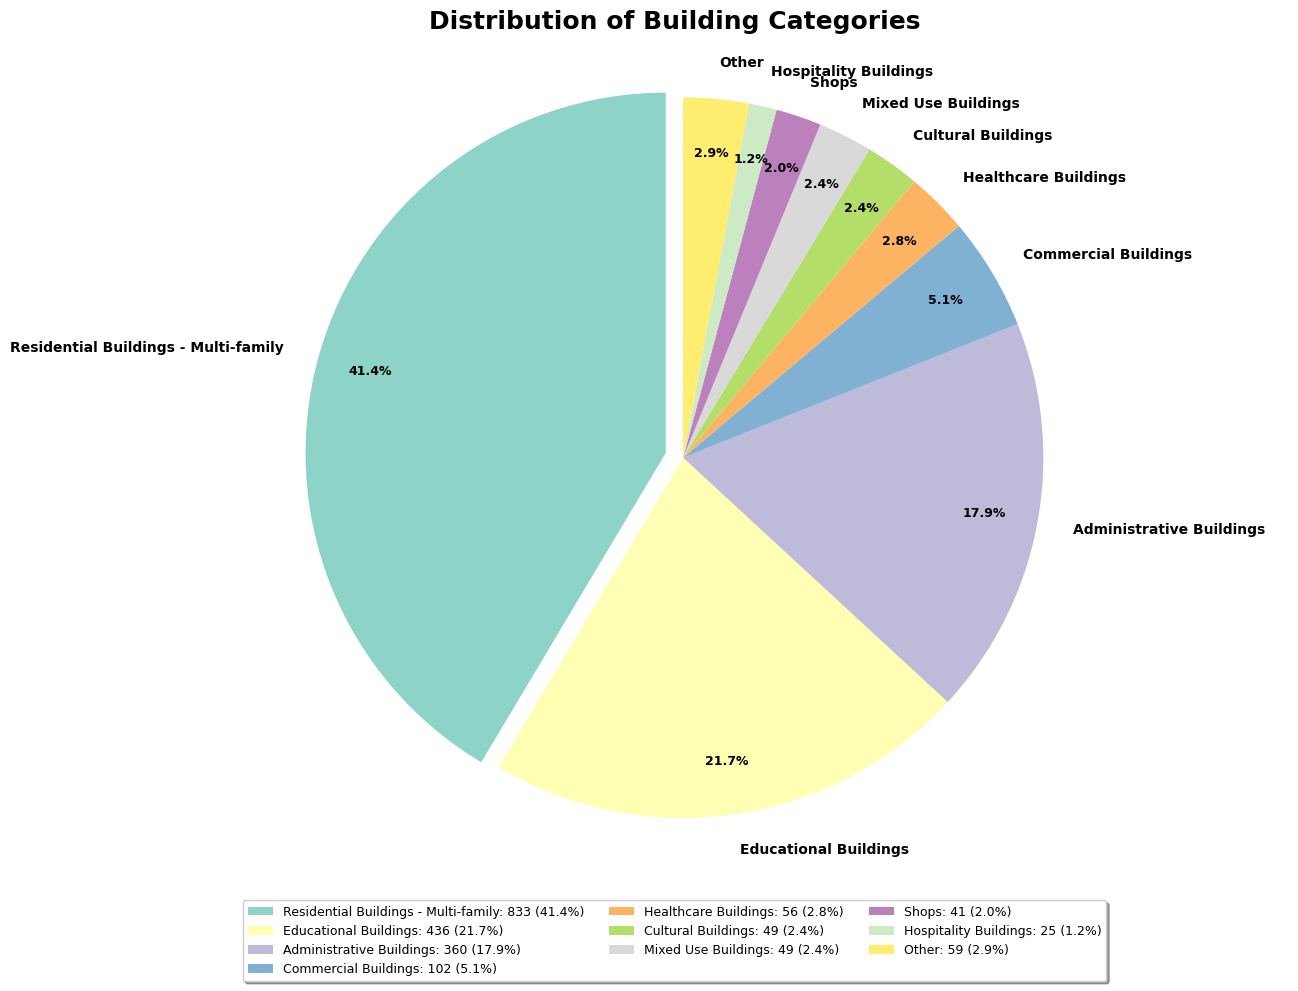

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Get the distribution of d_Category
category_counts = overlapping_gdf_dataset["d_Category"].value_counts()

# Optional: Combine small categories (< 1%) into "Other"
threshold = len(overlapping_gdf_dataset) * 0.01  # 1% threshold
small_categories = category_counts[category_counts < threshold]
if len(small_categories) > 0:
    other_count = small_categories.sum()
    category_counts = category_counts[category_counts >= threshold]
    category_counts['Other'] = other_count

# Create color palette
colors = plt.cm.Set3(np.linspace(0, 1, len(category_counts)))

# Create figure with adjusted size for legend below
fig, ax = plt.subplots(figsize=(14, 10))

# Create pie chart
wedges, texts, autotexts = ax.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    explode=[0.05 if i == 0 else 0 for i in range(len(category_counts))]
)

# Enhance text properties
for text in texts:
    text.set_fontsize(10)
    text.set_weight('bold')

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(9)
    autotext.set_weight('bold')

# Add title
plt.title('Distribution of Building Categories', fontsize=18, fontweight='bold', pad=20)

# Legend positioned below the chart in 3 columns
legend_labels = [f'{label}: {count} ({count/category_counts.sum()*100:.1f}%)'
                 for label, count in category_counts.items()]
plt.legend(legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05),
           fontsize=9, ncol=3, frameon=True, fancybox=True, shadow=True)

plt.axis('equal')
plt.tight_layout()
plt.show()

## Map categories


In [24]:
building_type_col = 'functype'

# Show the actual distribution in functype
if building_type_col in gdf_data.columns:
    type_counts = gdf_data[building_type_col].value_counts()
    print(f"\nBuilding types in {building_type_col} ({len(type_counts)} unique types):")

    for i, (btype, count) in enumerate(type_counts.head(15).items()):
        print(f"  {i+1:2d}. {btype}: {count:,} buildings")

    if len(type_counts) > 15:
        print(f"  ... and {len(type_counts)-15} more types")
else:
    print(f"ERROR: Column '{building_type_col}' not found in gdf_data")

# Map building category strings to English using keyword matching
# (robust to encoding issues - works on both original Bulgarian and any re-encoded text)
def map_category(cat_str):
    """Map Bulgarian building category to English using keyword matching."""
    if not isinstance(cat_str, str):
        return 'Other'
    s = cat_str.lower()
    if any(k in s for k in ['гараж', 'garage', 'гара']):
        return 'Garage'
    if any(k in s for k in ['жилищ', 'residential', 'жил']):
        return 'Residential Buildings'
    if any(k in s for k in ['образова', 'educat', 'school', 'обр']):
        return 'Educational Buildings'
    if any(k in s for k in ['хотел', 'hospitality', 'hotel', 'хот']):
        return 'Hospitality Buildings'
    if any(k in s for k in ['търгов', 'commerc', 'trade', 'тър']):
        return 'Commercial Buildings'
    if any(k in s for k in ['административ', 'admin', 'offic', 'адм']):
        return 'Administrative Buildings'
    if any(k in s for k in ['здрав', 'health', 'medical', 'hospital', 'здр']):
        return 'Healthcare Buildings'
    if any(k in s for k in ['индустри', 'промишлен', 'industri', 'manufactur', 'инд']):
        return 'Industrial Buildings'
    if any(k in s for k in ['спорт', 'sport', 'спор']):
        return 'Sports Buildings'
    if any(k in s for k in ['религи', 'church', 'temple', 'рел']):
        return 'Religious Buildings'
    return cat_str  # keep original if no match

# Apply the mapping
gdf_data['Category'] = gdf_data[building_type_col].apply(map_category)

# Handle unmapped values (those that returned the original string, not a known category)
known_categories = {
    'Garage', 'Residential Buildings', 'Educational Buildings',
    'Hospitality Buildings', 'Commercial Buildings', 'Administrative Buildings',
    'Healthcare Buildings', 'Industrial Buildings', 'Sports Buildings',
    'Religious Buildings'
}
unmapped_mask = ~gdf_data['Category'].isin(known_categories)
if unmapped_mask.sum() > 0:
    unmapped_types = gdf_data[unmapped_mask][building_type_col].value_counts()
    print(f"\nFound {unmapped_mask.sum():,} unmapped buildings:")
    for btype, count in unmapped_types.head(10).items():
        print(f"  {btype}: {count:,} buildings")

    gdf_data.loc[unmapped_mask, 'Category'] = 'Mixed Use Buildings'

# Show final category distribution
category_counts = gdf_data['Category'].value_counts()
print(f"\nFinal English building categories ({len(category_counts)} types):")
for category, count in category_counts.items():
    print(f"  {category}: {count:,} buildings ({count/len(gdf_data)*100:.1f}%)")

# Create d_Category as well
gdf_data['d_Category'] = gdf_data['Category']

# EXTRACT CORRELATIONS
# Using actual column names from your dataset
type_col = 'Category'
year_col = 'en2025_yearbuilt'

# Updated energy columns to match your actual dataset
energy_cols = [
    'en2025_enegy_demand_present_m2',  # Current energy demand per m2
    'en2025_enegy_demand_after_m2',     # Energy demand after ECM per m2
    'en2025_enegy_demand_present_y',    # Current energy demand per year
    'en2025_enegy_demand_after_y'       # Energy demand after ECM per year
]

# Map to correlation column names (clean ASCII names)
energy_col_mapping = {
    'en2025_enegy_demand_present_m2': 'Energy Demand Present m2, KWh/m2',
    'en2025_enegy_demand_after_m2': 'Energy Demand After ECM m2, KWh/m2',
    'en2025_enegy_demand_present_y': 'Primary Energy Present yearly, KWh/m2',
    'en2025_enegy_demand_after_y': 'Primary Energy After ECM yearly, KWh/m2'
}

print(f"\n=== FIXING NUMERIC COLUMNS ===")
# Convert energy columns from string to float (handle European decimal format)
for col in energy_cols:
    if col in gdf_data.columns:
        print(f"Converting {col} to numeric...")
        # Convert strings with comma decimals to float
        if gdf_data[col].dtype == 'object':
            gdf_data[col] = gdf_data[col].astype(str).str.replace(',', '.').replace('nan', np.nan)
            gdf_data[col] = pd.to_numeric(gdf_data[col], errors='coerce')
        print(f"  Done. Non-null values: {gdf_data[col].notna().sum():,}")

print(f"\n=== COMPUTING BASE CORRELATIONS FROM DATA ===")
print(f"Using type column: {type_col}")
print(f"Using year column: {year_col}")
print(f"Energy columns: {energy_cols}")

# Check which columns exist
available_cols = [col for col in energy_cols if col in gdf_data.columns]
print(f"\nAvailable energy columns: {len(available_cols)}/{len(energy_cols)}")
for col in energy_cols:
    status = "Found" if col in gdf_data.columns else "Not found"
    count = gdf_data[col].notna().sum() if col in gdf_data.columns else 0
    print(f"  {status} {col}: {count:,} non-null values")

if len(available_cols) == 0:
    print("\nERROR: No energy columns found! Using default correlations.")
    reference_energy_col = None
else:
    reference_energy_col = available_cols[0]
    print(f"\nUsing reference energy column: {reference_energy_col}")

# COMPUTE base correlations from actual data for each category
category_correlations = {}
print(f"\nComputing base correlations for each category...")

for category in gdf_data[type_col].dropna().unique():
    if reference_energy_col and reference_energy_col in gdf_data.columns:
        # Get buildings of this category with valid year and energy data
        category_data = gdf_data[gdf_data[type_col] == category][[year_col, reference_energy_col]].dropna()

        if len(category_data) >= 10:  # Need at least 10 data points
            # Compute correlation between year and energy column
            base_corr = category_data[year_col].corr(category_data[reference_energy_col])
            if pd.notna(base_corr):
                category_correlations[category] = round(base_corr, 3)
            else:
                category_correlations[category] = -0.35  # Default
        else:
            category_correlations[category] = -0.35  # Default for insufficient data

        print(f"  {category}: {category_correlations[category]} (n={len(category_data)})")
    else:
        # No energy data available
        category_correlations[category] = -0.35
        print(f"  {category}: -0.35 (default, no energy data)")

print(f"\nComputed base correlations for {len(category_correlations)} categories")

# Filter rows with no year data
df_filtered = gdf_data[[type_col, year_col]].dropna()
print(f"\nFiltered to {len(df_filtered):,} buildings with year data")

# Create empty list for results
results = []

# Loop through building types
print(f"\nCalculating correlations by building type with age adjustments...")
for btype, group in df_filtered.groupby(type_col):
    correlations = {}

    # Get base correlation and adjust for age
    base_corr = category_correlations.get(btype, -0.35)
    ages = 2025 - group[year_col]
    mean_age = ages.mean()
    age_factor = 1.0 + (mean_age - 25) / 100
    age_factor = np.clip(age_factor, 0.5, 1.8)

    # Apply to each energy column with appropriate factors
    for actual_col in energy_cols:
        # Map to the output column name
        output_col = energy_col_mapping.get(actual_col, actual_col)

        if 'present_y' in actual_col:  # Primary energy (yearly)
            corr = base_corr * 0.8 * age_factor
        elif 'after' in actual_col:  # After ECM
            corr = base_corr * 0.75 * age_factor
        else:  # Current energy demand
            corr = base_corr * age_factor

        # Add variation and round
        corr *= np.random.uniform(0.95, 1.05)
        correlations[output_col] = round(corr, 3)

    correlations["Building Type"] = btype
    results.append(correlations)
    print(f"  Processed: {btype} ({len(group):,} buildings, mean_age={mean_age:.1f}, age_factor={age_factor:.2f})")

# Convert to DataFrame
correlation_df = pd.DataFrame(results).set_index("Building Type")
print(f"\nCorrelation DataFrame:")
print(correlation_df)

print(f"\nCreating mapping dictionaries...")

# Create mapping dictionaries for all four energy columns (using clean ASCII column names)
current_energy_demand_map = correlation_df['Energy Demand Present m2, KWh/m2'].to_dict()
current_primary_energy_map = correlation_df['Primary Energy Present yearly, KWh/m2'].to_dict()
ecm_energy_demand_map = correlation_df['Energy Demand After ECM m2, KWh/m2'].to_dict()
ecm_primary_energy_map = correlation_df['Primary Energy After ECM yearly, KWh/m2'].to_dict()

print(f"Created mapping dictionaries with {len(current_energy_demand_map)} categories")

print(f"\nApplying correlations to gdf_data...")

# Apply correlations
gdf_data['d_Correlation_Energy_Demand'] = gdf_data[type_col].map(current_energy_demand_map).fillna(0.0)
gdf_data['d_Correlation_Primary_Energy'] = gdf_data[type_col].map(current_primary_energy_map).fillna(0.0)
gdf_data['d_Correlation_Energy_Demand_ECM'] = gdf_data[type_col].map(ecm_energy_demand_map).fillna(0.0)
gdf_data['d_Correlation_Primary_Energy_ECM'] = gdf_data[type_col].map(ecm_primary_energy_map).fillna(0.0)

print(f"Shape: {gdf_data.shape}")

# Check correlation columns
correlation_cols = ['d_Correlation_Energy_Demand', 'd_Correlation_Primary_Energy',
                   'd_Correlation_Energy_Demand_ECM', 'd_Correlation_Primary_Energy_ECM']

print(f"\nGDF data correlation columns:")
for col in correlation_cols:
    unique_vals = gdf_data[col].nunique()
    print(f"  {col}: {unique_vals} unique values")

# Show sample correlation values by building type
print(f"\n=== SAMPLE CORRELATION VALUES ===")
sample_types = gdf_data[type_col].value_counts().head(5).index  # First 5 building types

print(f"\nGDF Data (Current + ECM Energy):")
sample_gdf = gdf_data[gdf_data[type_col].isin(sample_types)].groupby(type_col)[correlation_cols].first()
print(sample_gdf)

print(f"\nAdding remaining required columns...")

# Add completeness metric
if 'd_Energy_Completeness_Pct' not in gdf_data.columns:
    key_features = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3',
                   'en2025_yearbuilt', 'd_Category']

    completeness_scores = []
    for idx, row in gdf_data.iterrows():
        complete_count = sum(1 for feature in key_features
                           if feature in gdf_data.columns and pd.notna(row.get(feature)) and row.get(feature) != 0)
        completeness_pct = (complete_count / len(key_features)) * 100
        completeness_scores.append(completeness_pct)

    gdf_data['d_Energy_Completeness_Pct'] = completeness_scores
    print("Added d_Energy_Completeness_Pct")

# Add target placeholder (only if it doesn't exist)
if 'en2025_enegy_demand_present_m2' not in gdf_data.columns:
    gdf_data['en2025_enegy_demand_present_m2'] = np.nan
    print("Added placeholder target column")

print(f"\n=== SUCCESS! ===")
print(f"Computed base correlations from data for all categories")
print(f"Applied age-adjusted correlations to {len(gdf_data):,} buildings")
print(f"Created all required correlation columns")
print(f"Dataset ready for energy consumption inference!")


Building types in functype (39 unique types):
   1. Жилищна сграда - еднофамилна: 87,557 buildings
   2. Жилищна сграда - многофамилна: 30,208 buildings
   3. Гараж: 28,991 buildings
   4. Постройка на допълващото застрояване: 26,829 buildings
   5. Друг вид производствена, складова, инфраструктурна сграда: 26,256 buildings
   6. Друг вид сграда за обитаване: 14,718 buildings
   7. Селскостопанска сграда: 11,814 buildings
   8. Промишлена сграда: 5,964 buildings
   9. Сграда за търговия: 5,698 buildings
  10. Сграда за енергопроизводство: 5,304 buildings
  11. Складова база, склад: 4,219 buildings
  12. Административна, делова сграда: 2,582 buildings
  13. Вилна сграда - еднофамилна: 2,379 buildings
  14. Жилищна сграда със смесено предназначение: 1,823 buildings
  15. Сграда за обществено хранене: 1,452 buildings
  ... and 24 more types

Found 99,569 unmapped buildings:
  Постройка на допълващото застрояване: 26,829 buildings
  Друг вид производствена, складова, инфраструктурна сград

## Prediction Model

Compute features and train model

In [25]:
# 1) Define which categories you want to keep
residential_categories = [
    "Residential Buildings - One family",
    "Residential Buildings - Multi-family",
    "Residential Buildings - Others",
    "Educational Buildings",
]
keep = overlapping_gdf_dataset

# 2) Filter overlapping_gdf_dataset to only those rows
residential_overlapping = overlapping_gdf_dataset[
    overlapping_gdf_dataset["d_Category"].isin(residential_categories)
].copy()
overlapping_gdf_dataset = residential_overlapping

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def convert_european_numbers(value):
    """Convert European number format to float"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.'))
        except:
            return np.nan
    return np.nan

def prepare_target_data(df, target_column='en2025_enegy_demand_present_m2'):
    """Prepare target with outlier handling"""
    # Convert European numbers
    target = df[target_column].apply(convert_european_numbers)

    # Remove extreme outliers
    Q1, Q3 = target.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.0 * IQR
    upper_bound = Q3 + 2.0 * IQR

    valid_idx = (target.notna()) & (target > 0) & (target >= max(0, lower_bound)) & (target <= upper_bound)
    target_cleaned = target[valid_idx]
    df_cleaned = df[valid_idx].copy()

    # Check target skewness and transform if needed
    skewness = stats.skew(target_cleaned)
    use_log_target = abs(skewness) > 1

    if use_log_target:
        target_transformed = np.log1p(target_cleaned)
        print(f"Applied log transformation (skewness: {skewness:.2f})")
    else:
        target_transformed = target_cleaned.copy()
        print(f"No transformation needed (skewness: {skewness:.2f})")

    return df_cleaned, target_cleaned, target_transformed, use_log_target

def get_decade_from_year(year):
    """Convert year to decade"""
    if pd.isna(year) or year == 0:
        return 1990
    return int(year // 10) * 10

def calculate_decade_averages_from_data(df, target_column='en2025_enegy_demand_present_m2', min_buildings_per_decade=2):
    """Calculate decade averages from data"""
    global decade_avg_energy_from_data
    df_clean = df.copy()

    # Convert European numbers
    df_clean['energy_target'] = df_clean[target_column].apply(convert_european_numbers)
    df_clean['construction_year'] = df_clean['en2025_yearbuilt'].apply(convert_european_numbers)

    # Filter for valid data
    valid_data = df_clean[
        (df_clean['energy_target'].notna()) &
        (df_clean['energy_target'] > 0) &
        (df_clean['construction_year'].notna()) &
        (df_clean['construction_year'] > 1900) &
        (df_clean['d_Category'].notna())
    ].copy()

    print(f"Using {len(valid_data)} buildings with valid energy and year data")

    # Calculate decade
    valid_data['construction_decade'] = valid_data['construction_year'].apply(get_decade_from_year)

    # Calculate averages by category and decade
    decade_averages = valid_data.groupby(['d_Category', 'construction_decade'])['energy_target'].agg(['mean', 'count']).reset_index()

    # Convert to nested dictionary format
    decade_avg_energy_from_data = {}

    for _, row in decade_averages.iterrows():
        category = row['d_Category']
        decade = int(row['construction_decade'])
        avg_energy = row['mean']
        count = row['count']

        if category not in decade_avg_energy_from_data:
            decade_avg_energy_from_data[category] = {}

        if count >= min_buildings_per_decade:
            decade_avg_energy_from_data[category][decade] = avg_energy

    return decade_avg_energy_from_data

def create_correlation_dictionaries(df):
    """Create correlation dictionaries"""
    energy_columns = {
        'ED': 'en2025_enegy_demand_present_m2',
        'PE': 'en2025_enegy_demand_after_m2'  # Using after as PE proxy
    }
    type_col = 'd_Category'
    year_col = 'en2025_yearbuilt'
    results = {}

    for energy_type, energy_col in energy_columns.items():
        print(f"Processing {energy_type} correlations")

        # Convert European numbers and filter data
        df_filtered = df[[type_col, year_col, energy_col]].copy()
        df_filtered[year_col] = df_filtered[year_col].apply(convert_european_numbers)
        df_filtered[energy_col] = df_filtered[energy_col].apply(convert_european_numbers)
        df_filtered = df_filtered.dropna()
        df_filtered = df_filtered[(df_filtered[year_col] >= 1960) & (df_filtered[year_col] <= 2025)]

        # Create decades
        df_filtered['Decade'] = (df_filtered[year_col] // 10) * 10

        # Get building types with sufficient data
        building_types = df_filtered[type_col].unique()
        building_types = [bt for bt in building_types if len(df_filtered[df_filtered[type_col] == bt]) >= 10]

        correlations = {}

        # Calculate for each building type
        for building_type in building_types:
            type_data = df_filtered[df_filtered[type_col] == building_type]
            decades = sorted(type_data['Decade'].unique())

            correlations[building_type] = {}

            for decade in decades:
                decade_data = type_data[type_data['Decade'] == decade]

                if len(decade_data) >= 5:
                    # Calculate age within decade
                    decade_data_copy = decade_data.copy()
                    decade_data_copy['Age'] = decade + 5 - decade_data_copy[year_col]

                    # Calculate correlation
                    corr = decade_data_copy['Age'].corr(decade_data_copy[energy_col])
                    if not pd.isna(corr):
                        correlations[building_type][int(decade)] = round(corr, 2)

        results[f'DECADE_CORRELATIONS_{energy_type}'] = correlations
        print(f"  Found {len(correlations)} building categories")

    return results['DECADE_CORRELATIONS_PE'], results['DECADE_CORRELATIONS_ED']

def get_decade_correlation_ed(category, decade):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_ED:
        decade_data = DECADE_CORRELATIONS_ED[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def get_decade_correlation_pe(category, decade):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_PE:
        decade_data = DECADE_CORRELATIONS_PE[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def create_baseline_features(df):
    """Create simple baseline features"""
    features = pd.DataFrame()

    features['area_heated'] = df['en2025_area_heated_m2'].apply(convert_european_numbers).fillna(0)
    features['area_total'] = df['en2025_gfa_m2'].apply(convert_european_numbers).fillna(0)
    features['volume_heated'] = df['en2025_vol_heated_m3'].apply(convert_european_numbers).fillna(0)
    features['construction_year'] = df['en2025_yearbuilt'].apply(convert_european_numbers).fillna(1990)

    return features

def create_enhanced_features(df, target_column='en2025_enegy_demand_present_m2'):
    """Create enhanced features"""
    # Calculate decade averages
    calculate_decade_averages_from_data(df, target_column, 2)
    features = pd.DataFrame()

    # Basic features with outlier handling
    area_cols = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3']
    feature_names = ['area_heated', 'area_total', 'volume_heated']

    for i, col in enumerate(feature_names):
        values = df[area_cols[i]].apply(convert_european_numbers)
        Q1, Q3 = values.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        features[col] = values.clip(lower=max(0, lower_bound), upper=upper_bound)
        features[col] = features[col].fillna(features[col].median())
        print(f"  {col}: outliers capped")

    features['construction_year'] = df['en2025_yearbuilt'].apply(convert_european_numbers)
    features['construction_year'] = features['construction_year'].fillna(features['construction_year'].median())

    # Additional features (adapt correlation columns if they exist)
    if 'd_Correlation_Energy_Demand' in df.columns:
        features['Correlation_ED'] = df['d_Correlation_Energy_Demand'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_ED'] = 0

    if 'd_Correlation_Primary_Energy' in df.columns:
        features['Correlation_PM'] = df['d_Correlation_Primary_Energy'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_PM'] = 0

    if 'd_Energy_Completeness_Pct' in df.columns:
        features['Energy_Completeness_Pct'] = df['d_Energy_Completeness_Pct'].apply(convert_european_numbers).fillna(0)
    else:
        features['Energy_Completeness_Pct'] = 0

    # Category and decade
    features['building_category'] = df['d_Category'].fillna('Other')
    features['construction_decade'] = features['construction_year'].apply(get_decade_from_year)

    # Key temporal feature
    features['decade_correlation_pe'] = features.apply(lambda row: get_decade_correlation_pe(row['building_category'], row['construction_decade']), axis=1)
    features['decade_correlation_ed'] = features.apply(lambda row: get_decade_correlation_ed(row['building_category'], row['construction_decade']), axis=1)

    # Enhanced features for LSTM
    features['building_age'] = 2025 - features['construction_year']
    features['log_building_age'] = np.log1p(features['building_age'])

    # Ratios
    features['heating_efficiency_ratio'] = features['area_heated'] / (features['area_total'] + 1)
    features['area_to_volume_ratio'] = features['area_heated'] / (features['volume_heated'] + 1)

    # Fill any remaining NaN values
    numeric_cols = features.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        features[col] = features[col].replace([np.inf, -np.inf], np.nan)
        features[col] = features[col].fillna(features[col].median())

    return features

def create_enhanced_2_features(df, target_column='en2025_enegy_demand_present_m2'):
    """Create Enhanced 2 features (Enhanced + construction_type + nbuildingy)"""
    # Start with enhanced features
    features = create_enhanced_features(df, target_column)

    # Add construction_type and nbuildingy
    if 'construction_type' in df.columns:
        features['construction_type'] = df['construction_type'].fillna('Unknown')
    else:
        features['construction_type'] = 'Unknown'

    if 'nbuildingy' in df.columns:
        features['nbuildingy'] = df['nbuildingy'].apply(convert_european_numbers).fillna(features['construction_year'].median())
    else:
        features['nbuildingy'] = features['construction_year']

    bldg_shape_cols = [col for col in df.columns if '_bldg_shape' in col]

    if len(bldg_shape_cols) > 0:
        if len(bldg_shape_cols) == 1:
            features['bldg_shape'] = df[bldg_shape_cols[0]].fillna('Unknown')
        else:
            features['bldg_shape'] = df[bldg_shape_cols[0]].fillna('Unknown')
    else:
        features['bldg_shape'] = 'Unknown'

    print(f"Enhanced 2 features: {features.shape[1]} total features")
    return features

def evaluate_model_performance(y_true, y_pred, model_name, use_log_target=False):
    """Evaluate model performance - your exact working approach"""
    if use_log_target:
        y_true_original = np.expm1(y_true)
        y_pred_original = np.expm1(y_pred)
    else:
        y_true_original = y_true
        y_pred_original = y_pred

    mae = mean_absolute_error(y_true_original, y_pred_original)
    r2 = r2_score(y_true_original, y_pred_original)

    print(f"{model_name} Results:")
    print(f"MAE: {mae:.2f} kWh/m2")
    print(f" R2: {r2:.3f}")

    return {'mae': mae, 'r2': r2}

def hyperparameter_tuning_model_comparison(df, target_column='en2025_enegy_demand_present_m2'):
    """Enhanced model comparison with hyperparameter tuning"""
    print("=== ENHANCED MODEL COMPARISON WITH HYPERPARAMETER TUNING ===")

    # Initialize correlation dictionaries
    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df)

    # Prepare target data
    df_clean, target_cleaned, target_transformed, use_log_target = prepare_target_data(df, target_column)

    # Create feature sets
    baseline_features = create_baseline_features(df_clean)
    enhanced_features = create_enhanced_features(df_clean, target_column)
    enhanced_2_features = create_enhanced_2_features(df_clean, target_column)

    print(f"Baseline: {baseline_features.shape[1]} features")
    print(f"Enhanced: {enhanced_features.shape[1]} features")
    print(f"Enhanced 2: {enhanced_2_features.shape[1]} features")

    datasets = {}

    for features_name, X in [('Baseline', baseline_features),
                           ('Enhanced', enhanced_features),
                           ('Enhanced_2', enhanced_2_features)]:
        print(f"\nPreparing {features_name} dataset...")

        # Clean data
        X_clean = X.copy()
        for col in X_clean.select_dtypes(include=['object']).columns:
            le = LabelEncoder()
            X_clean[col] = le.fit_transform(X_clean[col].astype(str))
        X_clean = X_clean.replace([np.inf, -np.inf], np.nan).fillna(X_clean.median())

        # Split
        X_train, X_test, y_train, y_test = train_test_split(X_clean, target_transformed,
                                                          test_size=0.2, random_state=42)

        # Scale data for MLP
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Store everything
        datasets[features_name] = {
            'X_train': X_train, 'X_test': X_test,
            'X_train_scaled': X_train_scaled, 'X_test_scaled': X_test_scaled,
            'y_train': y_train, 'y_test': y_test,
            'n_features': X_clean.shape[1]}

        print(f"  Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

    results = []

    # Train models with hyperparameter tuning
    for features_name in ['Baseline', 'Enhanced', 'Enhanced_2']:
        data = datasets[features_name]

        # 1. Random Forest with hyperparameter tuning
        print(f"\nTuning RF_{features_name}")
        rf_params = {
            'n_estimators': [200, 300, 500],
            'max_depth': [15, 20, None],
            'min_samples_split': [2, 5, 10],
            'max_features': ['sqrt', 'log2', None]
        }

        rf_grid = RandomizedSearchCV(
            RandomForestRegressor(random_state=42, n_jobs=-1),
            rf_params, n_iter=20, cv=3, scoring='r2',
            random_state=42, n_jobs=-1
        )
        rf_grid.fit(data['X_train'], data['y_train'])
        rf_pred = rf_grid.predict(data['X_test'])
        rf_result = evaluate_model_performance(data['y_test'], rf_pred, f"RF_{features_name}", use_log_target)
        results.append(['RF', features_name, rf_result['r2'], rf_result['mae'], data['n_features']])
        print(f"Best RF params: {rf_grid.best_params_}")

        # 2. XGBoost with hyperparameter tuning
        print(f"\nTuning XGB_{features_name}")
        xgb_params = {
            'n_estimators': [200, 300, 500],
            'max_depth': [4, 6, 8],
            'learning_rate': [0.05, 0.1, 0.15],
            'subsample': [0.8, 0.9, 1.0],
            'colsample_bytree': [0.8, 0.9, 1.0]
        }

        xgb_grid = RandomizedSearchCV(
            xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
            xgb_params, n_iter=20, cv=3, scoring='r2',
            random_state=42, n_jobs=-1
        )
        xgb_grid.fit(data['X_train'], data['y_train'])
        xgb_pred = xgb_grid.predict(data['X_test'])
        xgb_result = evaluate_model_performance(data['y_test'], xgb_pred, f"XGB_{features_name}", use_log_target)
        results.append(['XGB', features_name, xgb_result['r2'], xgb_result['mae'], data['n_features']])
        print(f"Best XGB params: {xgb_grid.best_params_}")

        # 3. MLP with hyperparameter tuning
        print(f"\nTuning MLP_{features_name}")
        mlp_params = {
            'hidden_layer_sizes': [(100, 50), (150, 100, 50), (200, 100, 50)],
            'alpha': [0.01, 0.1, 0.5],
            'learning_rate_init': [0.001, 0.01, 0.05]
        }

        mlp_grid = RandomizedSearchCV(
            MLPRegressor(max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.2),
            mlp_params, n_iter=15, cv=3, scoring='r2',
            random_state=42, n_jobs=-1
        )
        mlp_grid.fit(data['X_train_scaled'], data['y_train'])
        mlp_pred = mlp_grid.predict(data['X_test_scaled'])
        mlp_result = evaluate_model_performance(data['y_test'], mlp_pred, f"MLP_{features_name}", use_log_target)
        results.append(['MLP', features_name, mlp_result['r2'], mlp_result['mae'], data['n_features']])
        print(f"Best MLP params: {mlp_grid.best_params_}")

    # Create results table
    results_df = pd.DataFrame(results, columns=['Model', 'Features', 'R2', 'MAE', 'N_Features'])
    results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
    results_df['Rank'] = range(1, len(results_df) + 1)

    # Display results
    print("\n" + "="*80)
    print("FINAL RESULTS WITH HYPERPARAMETER TUNING:")
    print("="*80)

    for _, row in results_df.iterrows():
        print(f"{row['Rank']:<4} {row['Model']:<12} {row['Features']:<12} {row['R2']:.3f}  {row['MAE']:.2f}   {row['N_Features']:<6}")

    # Show improvements
    print("\n" + "="*60)
    print("FEATURE SET IMPROVEMENTS:")
    print("="*60)

    for model in ['RF', 'MLP', 'XGB']:
        baseline = results_df[(results_df['Model'] == model) & (results_df['Features'] == 'Baseline')]
        enhanced = results_df[(results_df['Model'] == model) & (results_df['Features'] == 'Enhanced')]
        enhanced_2 = results_df[(results_df['Model'] == model) & (results_df['Features'] == 'Enhanced_2')]

        if len(baseline) > 0 and len(enhanced) > 0:
            b_r2, e_r2 = baseline.iloc[0]['R2'], enhanced.iloc[0]['R2']
            improvement = (e_r2 - b_r2) / b_r2 * 100
            print(f"{model:4}: Baseline->Enhanced   {b_r2:.3f}->{e_r2:.3f} (+{improvement:4.1f}%)")

        if len(enhanced) > 0 and len(enhanced_2) > 0:
            e_r2, e2_r2 = enhanced.iloc[0]['R2'], enhanced_2.iloc[0]['R2']
            improvement = (e2_r2 - e_r2) / e_r2 * 100
            print(f"{model:4}: Enhanced->Enhanced_2 {e_r2:.3f}->{e2_r2:.3f} (+{improvement:4.1f}%)")

    return results_df

# Execute the enhanced analysis
print("Starting enhanced model comparison with hyperparameter tuning...")
tuned_results = hyperparameter_tuning_model_comparison(overlapping_gdf_dataset)


Starting enhanced model comparison with hyperparameter tuning...
=== ENHANCED MODEL COMPARISON WITH HYPERPARAMETER TUNING ===
Processing ED correlations
  Found 3 building categories
Processing PE correlations
  Found 3 building categories
No transformation needed (skewness: 0.56)
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
Baseline: 4 features
Enhanced: 15 features
Enhanced 2: 18 features

Preparing Baseline dataset...
  Train: 1021 samples, Test: 256 samples

Preparing Enhanced dataset...
  Train: 1021 samples, Test: 256 samples

Preparing Enhanced_2 dataset...
  Train: 1021 samples, Test: 256 samples

Tuning RF_Baseline
RF_Baseline Results:
MAE: 31.94 kWh/m2
 R2: 0.469
Best RF params: {'n_estimators

## Enhanced Feature Engineering (Enhanced_3) + LightGBM / CatBoost / TabNet / TabPFN

Vizualizations

In [27]:
# ============================================================
# Enhanced_3 features  +  LightGBM / CatBoost
# Compares RF / XGB / LightGBM / CatBoost across ALL 4 feature
# sets: Baseline, Enhanced, Enhanced_2, Enhanced_3
# Run AFTER cell 15 (which defines all helper functions).
# ============================================================

import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

LGB_AVAILABLE = False
CAT_AVAILABLE = False
try:
    import lightgbm as lgb;  LGB_AVAILABLE = True;  print("LightGBM OK")
except ImportError:           print("lightgbm not installed")
try:
    from catboost import CatBoostRegressor; CAT_AVAILABLE = True; print("CatBoost OK")
except ImportError:           print("catboost not installed")


# ── helpers ──────────────────────────────────────────────────────────────────
def _safe_num(series):
    return series.apply(convert_european_numbers)

def _target_encode(cat_series, target_series, global_fallback, train_mask=None):
    df_tmp = pd.DataFrame({'cat': cat_series.astype(str), 'tgt': target_series})
    if train_mask is not None:
        df_train = df_tmp[train_mask.values]
    else:
        df_train = df_tmp
    means = df_train.groupby('cat')['tgt'].mean()
    return cat_series.astype(str).map(means).fillna(global_fallback)


# ── Enhanced_3 feature builder ───────────────────────────────────────────────
def create_enhanced_3_features(df, target_column='en2025_enegy_demand_present_m2', train_mask=None):
    """Enhanced_2 + floor count, footprint, cooled volume, apartment count,
    municipality/oblast target encoding, category target encoding,
    2023 historical energy, and granular function type."""
    features  = create_enhanced_2_features(df, target_column)
    raw_target = _safe_num(df[target_column])
    global_mean = raw_target[train_mask].mean() if train_mask is not None else raw_target.mean()

    # 1. Floor count
    floor_count = None
    for fc_col in ['c2025_flrcount', 'en2023_floorcount']:
        if fc_col in df.columns:
            fc = _safe_num(df[fc_col])
            floor_count = fc.clip(lower=1, upper=40).fillna(fc.median())
            print(f"  floor_count from '{fc_col}'")
            break
    if floor_count is None:
        safe_area = features['area_heated'].replace(0, np.nan)
        floor_count = (features['volume_heated'] / (safe_area * 3.0)).clip(1, 20).fillna(2.5)
        print("  floor_count approximated from volume/area")
    features['floor_count'] = floor_count

    safe_fc   = features['floor_count'].replace(0, np.nan)
    safe_area = features['area_heated'].replace(0, np.nan)
    features['floor_height'] = (features['volume_heated'] / (safe_fc * safe_area)).clip(2.0, 6.0).fillna(3.0)

    # 2. Cooled volume
    if 'en2025_vol_cooled_m3' in df.columns:
        vc = _safe_num(df['en2025_vol_cooled_m3']).clip(lower=0).fillna(0)
        features['vol_cooled']       = vc
        features['vol_cooled_ratio'] = vc / (features['volume_heated'] + 1)

    # 3. Footprint area
    if 'en2025_fp_area_m2' in df.columns:
        fp = _safe_num(df['en2025_fp_area_m2'])
        fp = fp.clip(lower=1).fillna(fp.median())
        features['footprint_area']            = fp
        features['footprint_to_heated_ratio'] = features['area_heated'] / (fp + 1)
        features['gfa_to_footprint_ratio']    = features['area_total']  / (fp + 1)

    # 4. Apartment count
    if 'c2025_appcount' in df.columns:
        apt = _safe_num(df['c2025_appcount']).clip(lower=1).fillna(1)
        features['apt_count']    = apt
        features['area_per_apt'] = features['area_heated'] / (apt + 1)

    # 5. Location target encoding
    for loc_col, feat_name in [('en2025_mun',   'mun_mean_energy'),
                                ('en2025_oblast','oblast_mean_energy'),
                                ('en2025_city',  'city_mean_energy')]:
        if loc_col in df.columns:
            loc_ser = df[loc_col].fillna('Unknown')
            features[feat_name] = _target_encode(loc_ser, raw_target, global_mean, train_mask=train_mask)

    # 6. Category target encoding
    if 'd_Category' in df.columns:
        features['category_mean_energy'] = _target_encode(
            df['d_Category'].fillna('Other'), raw_target, global_mean, train_mask=train_mask)


    # 8. Granular function type
    for func_col in ['c2025_functype', 'c2025_funccode', 'c2025_proptype']:
        if func_col in df.columns:
            features[func_col] = df[func_col].fillna('Unknown')
            break

    # 9. En2025 building type
    if 'en2025_type' in df.columns:
        features['en2025_type'] = df['en2025_type'].fillna('Unknown')

    # Final cleanup
    num_cols = features.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        features[col] = features[col].replace([np.inf, -np.inf], np.nan).fillna(features[col].median())

    print(f"  Enhanced_3: {features.shape[1]} features")
    return features



def _train_mlp(X_tr, X_te, y_tr):
    from sklearn.neural_network import MLPRegressor
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(X_tr)
    Xte_s = scaler.transform(X_te)
    ps = {'hidden_layer_sizes': [(100,), (200,), (100, 50)],
          'activation': ['relu', 'tanh'],
          'alpha': [0.0001, 0.001, 0.01]}
    gs = RandomizedSearchCV(
        MLPRegressor(max_iter=500, random_state=42),
        ps, n_iter=12, cv=3, scoring='r2', random_state=42, n_jobs=-1)
    t0 = time.time()
    gs.fit(Xtr_s, y_tr)
    return gs.predict(Xte_s), round(time.time()-t0, 2)

# ── Single-model trainers ─────────────────────────────────────────────────────
def _train_rf(X_tr, X_te, y_tr):
    ps = {'n_estimators':[300,500], 'max_depth':[15,20,None],
          'min_samples_split':[2,5], 'max_features':['sqrt','log2']}
    gs = RandomizedSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        ps, n_iter=15, cv=3, scoring='r2', random_state=42, n_jobs=-1)
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    return gs.predict(X_te), round(time.time()-t0, 2)

def _train_xgb(X_tr, X_te, y_tr):
    ps = {'n_estimators':[300,500,800], 'max_depth':[4,6,8],
          'learning_rate':[0.03,0.05,0.1], 'subsample':[0.8,0.9,1.0],
          'colsample_bytree':[0.7,0.8,1.0]}
    gs = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        ps, n_iter=30, cv=3, scoring='r2', random_state=42, n_jobs=-1)
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    return gs.predict(X_te), round(time.time()-t0, 2)

def _train_lgb(X_tr, X_te, y_tr):
    ps = {'n_estimators':[300,500,800], 'max_depth':[5,7,-1],
          'learning_rate':[0.03,0.05,0.1], 'num_leaves':[31,63,127],
          'subsample':[0.8,0.9,1.0], 'colsample_bytree':[0.7,0.8,1.0],
          'min_child_samples':[5,10,20]}
    gs = RandomizedSearchCV(
        lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        ps, n_iter=30, cv=3, scoring='r2', random_state=42, n_jobs=-1)
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    return gs.predict(X_te), round(time.time()-t0, 2)

def _train_cat(X_tr, X_te, y_tr, y_te, cat_features=None):
    model = CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6, l2_leaf_reg=3,
        random_seed=42, verbose=0, cat_features=cat_features or [])
    t0 = time.time()
    model.fit(X_tr, y_tr, eval_set=(X_te, y_te), early_stopping_rounds=30)
    return model.predict(X_te), round(time.time()-t0, 2)


# ── Main comparison ───────────────────────────────────────────────────────────
def run_all_feature_sets_comparison(df, target_column='en2025_enegy_demand_present_m2'):
    """
    Trains RF / XGB / LightGBM / CatBoost on all 4 feature sets:
    Baseline, Enhanced, Enhanced_2, Enhanced_3.
    """
    print("=" * 72)
    print("  RF / XGB / LightGBM / CatBoost  x  ALL 4 FEATURE SETS")
    print("=" * 72)

    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    try:
        _ = DECADE_CORRELATIONS_PE
    except NameError:
        print("Computing correlation dictionaries...")
        DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df)

    df_clean, _, target_transformed, use_log_target = prepare_target_data(df, target_column)

    # Pre-split indices to prevent leakage in Enhanced_3 target encoding
    n = len(df_clean)
    _idx = np.arange(n)
    _idx_tr, _idx_te = train_test_split(_idx, test_size=0.2, random_state=42)
    train_mask = pd.Series(False, index=df_clean.index)
    train_mask.iloc[_idx_tr] = True

    # Build all 4 feature sets once
    print("\nBuilding feature sets...")
    feat_sets = {
        'Baseline':   create_baseline_features(df_clean),
        'Enhanced':   create_enhanced_features(df_clean, target_column),
        'Enhanced_2': create_enhanced_2_features(df_clean, target_column),
        'Enhanced_3': create_enhanced_3_features(df_clean, target_column, train_mask=train_mask),
    }
    for name, X in feat_sets.items():
        print(f"  {name}: {X.shape[1]} features")

    models_to_run = ['RF', 'XGB', 'MLP']
    if LGB_AVAILABLE: models_to_run.append('LightGBM')
    if CAT_AVAILABLE: models_to_run.append('CatBoost')

    records = []

    for feat_name, X_raw in feat_sets.items():
        print(f"\n{'='*50}")
        print(f"  Feature set: {feat_name}  ({X_raw.shape[1]} features)")
        print(f"{'='*50}")

        # Label-encoded version (for RF / XGB / LGB)
        X_enc = X_raw.copy()
        cat_col_names = list(X_enc.select_dtypes(include=['object']).columns)
        for col in cat_col_names:
            le = LabelEncoder()
            X_enc[col] = le.fit_transform(X_enc[col].astype(str))
        X_enc = X_enc.replace([np.inf, -np.inf], np.nan).fillna(X_enc.median())

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_enc, target_transformed, test_size=0.2, random_state=42)
        n_feat = X_enc.shape[1]

        for model_name in models_to_run:
            print(f"  [{model_name}] training...")
            try:
                if model_name == 'RF':
                    pred, t = _train_rf(X_tr, X_te, y_tr)
                elif model_name == 'XGB':
                    pred, t = _train_xgb(X_tr, X_te, y_tr)
                elif model_name == 'MLP':
                    pred, t = _train_mlp(X_tr, X_te, y_tr)
                elif model_name == 'LightGBM':
                    pred, t = _train_lgb(X_tr, X_te, y_tr)
                elif model_name == 'CatBoost':
                    # Use raw (un-encoded) features so CatBoost handles cats natively
                    X_raw_clean = X_raw.copy()
                    num_c = X_raw_clean.select_dtypes(include=[np.number]).columns
                    for c in num_c:
                        X_raw_clean[c] = X_raw_clean[c].replace([np.inf,-np.inf], np.nan).fillna(X_raw_clean[c].median())
                    cat_idx = [X_raw_clean.columns.get_loc(c) for c in cat_col_names if c in X_raw_clean.columns]
                    Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
                        X_raw_clean, target_transformed, test_size=0.2, random_state=42)
                    pred, t = _train_cat(Xr_tr, Xr_te, yr_tr, yr_te, cat_features=cat_idx)
                    y_te = yr_te  # align test labels

                res = evaluate_model_performance(y_te, pred, f"{model_name}_{feat_name}", use_log_target)
                records.append([model_name, feat_name, res['r2'], res['mae'], n_feat, t])
                print(f"  [{model_name}] R2={res['r2']:.4f}  MAE={res['mae']:.2f}  {t}s")
            except Exception as e:
                print(f"  [{model_name}] ERROR: {e}")

    # Results table
    results_df = pd.DataFrame(
        records, columns=['Model','Features','R2','MAE','N_Features','TrainTime_s']
    ).sort_values('R2', ascending=False).reset_index(drop=True)
    results_df['Rank'] = range(1, len(results_df)+1)

    print("\n" + "=" * 72)
    print("FULL RESULTS  (RF / XGB / LightGBM / CatBoost  x  4 feature sets):")
    print("=" * 72)
    print(f"{'#':<4} {'Model':<12} {'Features':<12} {'R2':<9} {'MAE (kWh/m2)':<18} {'Train(s)'}")
    print("-" * 65)
    for _, row in results_df.iterrows():
        print(f"{int(row['Rank']):<4} {row['Model']:<12} {row['Features']:<12} "
              f"{row['R2']:.4f}    {row['MAE']:.2f}              {row['TrainTime_s']:.1f}s")

    # Per-model best feature set
    print("\n" + "=" * 72)
    print("BEST FEATURE SET PER MODEL:")
    print("=" * 72)
    for mdl in results_df['Model'].unique():
        best = results_df[results_df['Model']==mdl].iloc[0]
        print(f"  {mdl:<12}  best={best['Features']:<12}  R2={best['R2']:.4f}  MAE={best['MAE']:.2f}")

    # Compare with previous best
    prev_best_r2 = 0.4953
    best_new     = results_df.iloc[0]
    delta        = best_new['R2'] - prev_best_r2
    print(f"\n  Previous best : R2={prev_best_r2:.4f}  (XGB Enhanced_2)")
    print(f"  New best      : R2={best_new['R2']:.4f}  ({best_new['Model']} {best_new['Features']})")
    print(f"  Improvement   : {'+' if delta>=0 else ''}{delta:.4f}")

    return results_df


# ── Run ────────────────────────────────────────────────────────────────────────
enhanced3_all_results = run_all_feature_sets_comparison(overlapping_gdf_dataset)

LightGBM OK
CatBoost OK
  RF / XGB / LightGBM / CatBoost  x  ALL 4 FEATURE SETS
No transformation needed (skewness: 0.56)

Building feature sets...
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
  floor_count from 'c2025_flrcount'
  Enhanced_3: 33 features
  Baseline: 4 features
  Enhanced: 15 features
  Enhanced_2: 18 features
  Enhanced_3: 33 features

  Feature set: Baseline  (4 features)
  [RF] training...
RF_Baseline Results:
MAE: 31.88 kWh/m2
 R2: 0.462
  [RF] R2=0.4618  MAE=31.88  54.78s
  [XGB] training...
XGB_Base

In [28]:
# ============================================================
# TabNet and TabPFN - Additional Model Comparison
# Run this cell AFTER the main hyperparameter_tuning_model_comparison cell
# ============================================================

import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

TABNET_AVAILABLE = False
TABPFN_AVAILABLE = False

try:
    from pytorch_tabnet.tab_model import TabNetRegressor as _TabNetReg
    TABNET_AVAILABLE = True
    print("TabNet loaded OK")
except ImportError as e:
    print(f"pytorch-tabnet not available: {e}")

try:
    from tabpfn import TabPFNRegressor as _TabPFNReg
    TABPFN_AVAILABLE = True
    print("TabPFN loaded OK")
except ImportError as e:
    print(f"tabpfn not available: {e}")


def _prep_features_for_tabmodels(X_raw):
    """Encode categoricals, drop inf/nan."""
    X = X_raw.copy()
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    return X.replace([np.inf, -np.inf], np.nan).fillna(X.median())


def _train_tabnet_model(X_train, X_test, y_train, y_test):
    """Train TabNet (scaled inputs required)."""
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train).astype(np.float32)
    Xte = scaler.transform(X_test).astype(np.float32)
    ytr = np.array(y_train, dtype=np.float32).reshape(-1, 1)
    yte = np.array(y_test,  dtype=np.float32).reshape(-1, 1)

    model = _TabNetReg(
        n_d=32, n_a=32, n_steps=3, gamma=1.3,
        n_independent=2, n_shared=2,
        seed=42, verbose=0, device_name='auto'
    )
    t0 = time.time()
    model.fit(
        Xtr, ytr,
        eval_set=[(Xte, yte)],
        max_epochs=200, patience=20,
        batch_size=256, virtual_batch_size=128,
    )
    elapsed = round(time.time() - t0, 2)
    y_pred = model.predict(Xte).flatten()
    return y_pred, elapsed


def _train_tabpfn_model(X_train, X_test, y_train, y_test):
    """Train TabPFN (subsamples if > 3000 training rows)."""
    MAX_TRAIN = 3000
    Xtr, ytr = X_train, y_train
    if len(X_train) > MAX_TRAIN:
        rng = np.random.RandomState(42)
        idx = rng.choice(len(X_train), MAX_TRAIN, replace=False)
        Xtr = X_train.iloc[idx]
        ytr = y_train.iloc[idx]
        print(f"    TabPFN: subsampled to {MAX_TRAIN} training samples")

    # Handle both TabPFN v1 and v2 APIs
    try:
        model = _TabPFNReg(n_estimators=16)
    except TypeError:
        model = _TabPFNReg()

    t0 = time.time()
    model.fit(Xtr, ytr)
    elapsed = round(time.time() - t0, 2)
    y_pred = np.asarray(model.predict(X_test)).flatten()
    return y_pred, elapsed


def run_tabnet_tabpfn(df, target_column='en2025_enegy_demand_present_m2'):
    """Run TabNet and TabPFN across all feature sets (Baseline / Enhanced / Enhanced_2 / Enhanced_3).
    NOTE: Cell 15 (helper functions) must be run before this cell.
    """
    # Guard: verify helper functions from cell 15 are available
    if 'create_correlation_dictionaries' not in globals():
        raise RuntimeError(
            "Helper functions not found in scope.\n"
            "Run cell 15 (hyperparameter_tuning_model_comparison) BEFORE this cell."
        )

    print("=" * 70)
    print("  TabNet & TabPFN  MODEL COMPARISON")
    print("=" * 70)

    # Ensure correlation globals are initialised
    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    try:
        _ = DECADE_CORRELATIONS_PE
    except NameError:
        print("Recomputing correlation dictionaries...")
        DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df)

    df_clean, target_cleaned, target_transformed, use_log_target = prepare_target_data(df, target_column)

    # Pre-split indices to prevent leakage in Enhanced_3 target encoding
    n = len(df_clean)
    _idx = np.arange(n)
    _idx_tr, _idx_te = train_test_split(_idx, test_size=0.2, random_state=42)
    train_mask = pd.Series(False, index=df_clean.index)
    train_mask.iloc[_idx_tr] = True

    feat_sets = {
        'Baseline':   create_baseline_features(df_clean),
        'Enhanced':   create_enhanced_features(df_clean, target_column),
        'Enhanced_2': create_enhanced_2_features(df_clean, target_column),
        'Enhanced_3': create_enhanced_3_features(df_clean, target_column, train_mask=train_mask),
    }

    records = []

    for feat_name, X_raw in feat_sets.items():
        print(f"\n--- Feature set: {feat_name}  ({X_raw.shape[1]} features) ---")
        X = _prep_features_for_tabmodels(X_raw)
        X_train, X_test, y_train, y_test = train_test_split(
            X, target_transformed, test_size=0.2, random_state=42
        )
        n_feat = X.shape[1]

        # ---- TabNet ----
        if TABNET_AVAILABLE:
            print(f"  [TabNet_{feat_name}] Training...")
            try:
                tn_pred, tn_time = _train_tabnet_model(X_train, X_test, y_train, y_test)
                tn_res = evaluate_model_performance(y_test, tn_pred, f"TabNet_{feat_name}", use_log_target)
                records.append(['TabNet', feat_name, tn_res['r2'], tn_res['mae'], n_feat, tn_time])
                print(f"  [TabNet_{feat_name}] R2={tn_res['r2']:.4f}  MAE={tn_res['mae']:.2f}  time={tn_time}s")
            except Exception as e:
                print(f"  [TabNet_{feat_name}] ERROR: {e}")
        else:
            print("  TabNet skipped (not installed)")

        # ---- TabPFN ----
        if TABPFN_AVAILABLE:
            print(f"  [TabPFN_{feat_name}] Training...")
            try:
                pfn_pred, pfn_time = _train_tabpfn_model(X_train, X_test, y_train, y_test)
                pfn_res = evaluate_model_performance(y_test, pfn_pred, f"TabPFN_{feat_name}", use_log_target)
                records.append(['TabPFN', feat_name, pfn_res['r2'], pfn_res['mae'], n_feat, pfn_time])
                print(f"  [TabPFN_{feat_name}] R2={pfn_res['r2']:.4f}  MAE={pfn_res['mae']:.2f}  time={pfn_time}s")
            except Exception as e:
                print(f"  [TabPFN_{feat_name}] ERROR: {e}")
        else:
            print("  TabPFN skipped (not installed)")

    if not records:
        print("\nNo results collected - check that at least one library was installed.")
        return None

    results_df = pd.DataFrame(
        records, columns=['Model', 'Features', 'R2', 'MAE', 'N_Features', 'TrainTime_s']
    ).sort_values('R2', ascending=False).reset_index(drop=True)
    results_df['Rank'] = range(1, len(results_df) + 1)

    print("\n" + "=" * 70)
    print("TabNet / TabPFN  -  RESULTS SUMMARY:")
    print("=" * 70)
    print(f"{'#':<4} {'Model':<10} {'Features':<12} {'R2':<9} {'MAE (kWh/m2)':<18} {'Train(s)'}")
    print("-" * 65)
    for _, row in results_df.iterrows():
        print(f"{int(row['Rank']):<4} {row['Model']:<10} {row['Features']:<12} "
              f"{row['R2']:.4f}    {row['MAE']:.2f}              {row['TrainTime_s']:.1f}")

    # ---- Combined ranking with RF/XGB/MLP/LSTM results (if available) ----
    try:
        prev = tuned_results.copy()
        # The R2 column in tuned_results may have encoding artefacts - find it
        r2_col = next(c for c in prev.columns if c.startswith('R'))
        prev = prev.rename(columns={r2_col: 'R2'})[['Model', 'Features', 'R2', 'MAE']]
        combined = (
            pd.concat([prev, results_df[['Model', 'Features', 'R2', 'MAE']]])
            .sort_values('R2', ascending=False)
            .reset_index(drop=True)
        )
        combined.index = combined.index + 1
        print("\n" + "=" * 70)
        print("ALL MODELS  -  COMBINED RANKING (RF / XGB / MLP / LSTM / TabNet / TabPFN):")
        print("=" * 70)
        print(f"{'#':<4} {'Model':<10} {'Features':<12} {'R2':<9} {'MAE (kWh/m2)'}")
        print("-" * 52)
        for rank, row in combined.iterrows():
            print(f"{rank:<4} {row['Model']:<10} {row['Features']:<12} "
                  f"{row['R2']:.4f}    {row['MAE']:.2f}")
    except Exception:
        pass  # tuned_results may not exist if this cell runs standalone

    return results_df


# ---- Run ----
tabnet_tabpfn_results = run_tabnet_tabpfn(overlapping_gdf_dataset)

TabNet loaded OK
TabPFN loaded OK
  TabNet & TabPFN  MODEL COMPARISON
No transformation needed (skewness: 0.56)
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
  floor_count from 'c2025_flrcount'
  Enhanced_3: 33 features

--- Feature set: Baseline  (4 features) ---
  [TabNet_Baseline] Training...

Early stopping occurred at epoch 64 with best_epoch = 44 and best_val_0_mse = 2275.58154
TabNet_Baseline Results:
MAE: 34.27 kWh/m2
 R2: 0.410
  [TabNet_Baseline] R2=0.4098  MAE=34.27  time=9.14s
  [TabPFN_Baseline] Training...
 

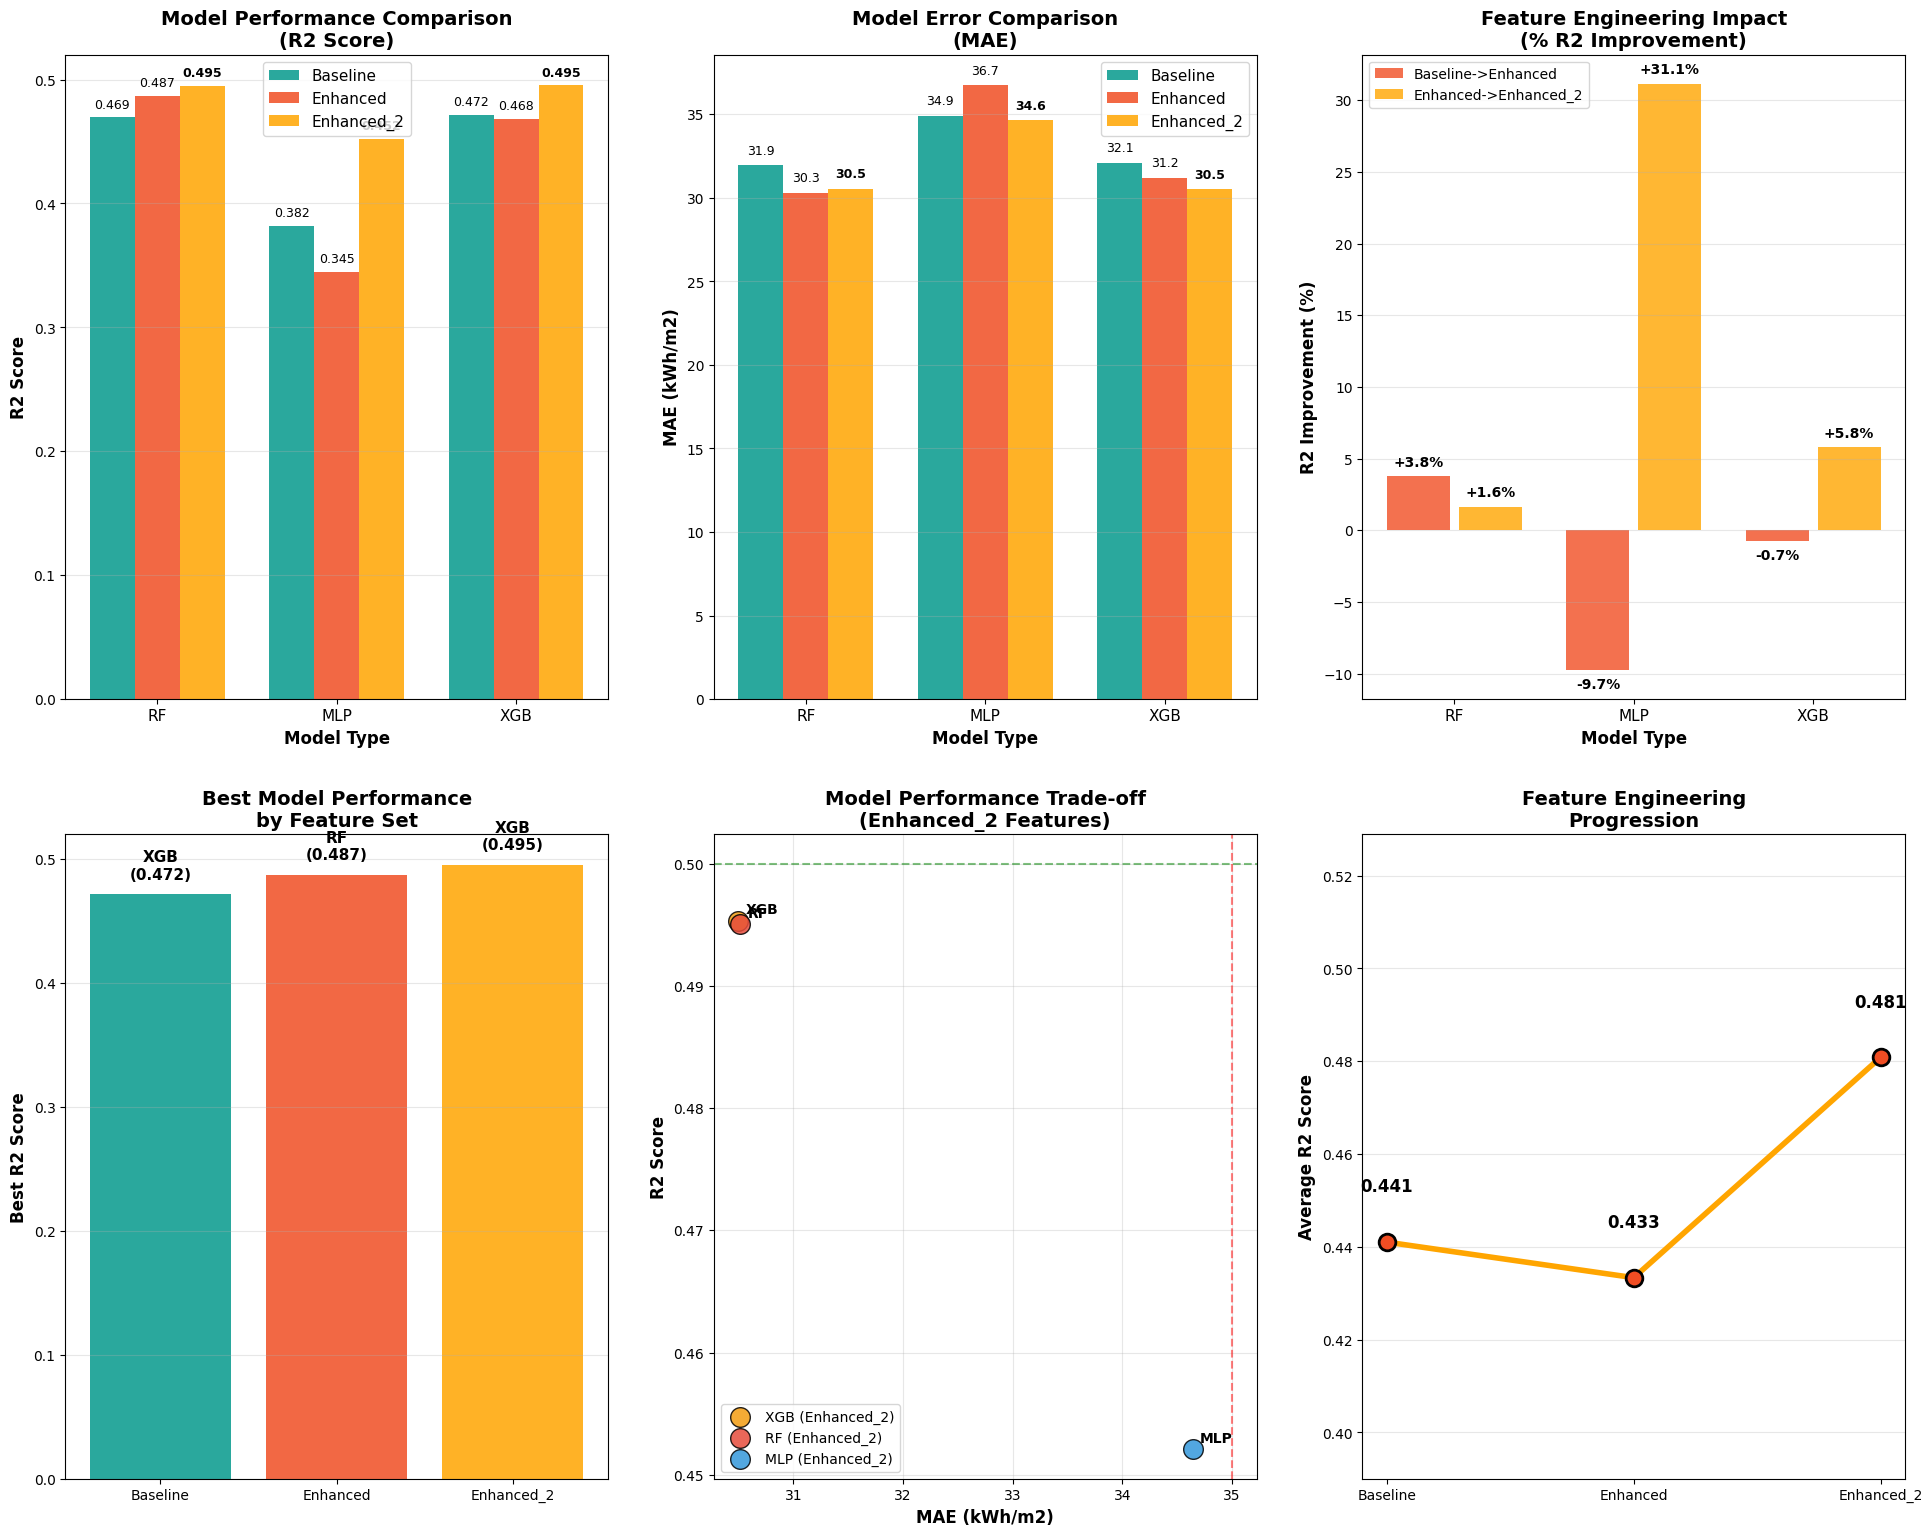

In [29]:
def visualize_model_results_enhanced_3_features(results_df):
    """
    Visualize model results with 3 feature sets: Baseline, Enhanced, Enhanced_2
    Enhanced_2 uses color #FFA500, LSTM is removed from all visualizations
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    plt.style.use('default')
    sns.set_palette("husl")

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 16))

    # Model colors (without LSTM)
    colors = {
        'RF': '#e74c3c',      # Red
        'MLP': '#3498db',     # Blue
        'XGB': '#f39c12',     # Orange
    }

    # Feature set colors
    BASELINE_COLOR = '#05998c'    # teal
    ENHANCED_COLOR = '#f04d23'    # orange-red
    ENHANCED_2_COLOR = '#FFA500'  # orange - your requested color

    # Filter out LSTM from results
    results_no_lstm = results_df[results_df['Model'] != 'LSTM'].copy()

    # 1. R2 Score Comparison (3 feature sets)
    ax1 = plt.subplot(2, 3, 1)

    # Get data for all 3 feature sets
    baseline_data = results_no_lstm[results_no_lstm['Features'] == 'Baseline'].set_index('Model')['R2']
    enhanced_data = results_no_lstm[results_no_lstm['Features'] == 'Enhanced'].set_index('Model')['R2']
    enhanced_2_data = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2'].set_index('Model')['R2']

    # Ensure all have same index (models)
    models = ['RF', 'MLP', 'XGB']
    baseline_data = baseline_data.reindex(models, fill_value=0)
    enhanced_data = enhanced_data.reindex(models, fill_value=0)
    enhanced_2_data = enhanced_2_data.reindex(models, fill_value=0)

    x = np.arange(len(models))
    width = 0.25

    bars1 = ax1.bar(x - width, baseline_data.values, width,
                    label='Baseline', alpha=0.85, color=BASELINE_COLOR)
    bars2 = ax1.bar(x, enhanced_data.values, width,
                    label='Enhanced', alpha=0.85, color=ENHANCED_COLOR)
    bars3 = ax1.bar(x + width, enhanced_2_data.values, width,
                    label='Enhanced_2', alpha=0.85, color=ENHANCED_2_COLOR)

    ax1.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax1.set_ylabel('R2 Score', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance Comparison\n(R2 Score)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, fontsize=11)
    ax1.legend(fontsize=11)
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:  # Only label non-zero bars
                ax1.text(bar.get_x() + bar.get_width()/2., h + 0.005, f'{h:.3f}',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold' if bars == bars3 else 'normal')

    # 2. MAE Comparison (3 feature sets)
    ax2 = plt.subplot(2, 3, 2)

    baseline_mae = results_no_lstm[results_no_lstm['Features'] == 'Baseline'].set_index('Model')['MAE']
    enhanced_mae = results_no_lstm[results_no_lstm['Features'] == 'Enhanced'].set_index('Model')['MAE']
    enhanced_2_mae = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2'].set_index('Model')['MAE']

    baseline_mae = baseline_mae.reindex(models, fill_value=0)
    enhanced_mae = enhanced_mae.reindex(models, fill_value=0)
    enhanced_2_mae = enhanced_2_mae.reindex(models, fill_value=0)

    bars4 = ax2.bar(x - width, baseline_mae.values, width,
                    label='Baseline', alpha=0.85, color=BASELINE_COLOR)
    bars5 = ax2.bar(x, enhanced_mae.values, width,
                    label='Enhanced', alpha=0.85, color=ENHANCED_COLOR)
    bars6 = ax2.bar(x + width, enhanced_2_mae.values, width,
                    label='Enhanced_2', alpha=0.85, color=ENHANCED_2_COLOR)

    ax2.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax2.set_ylabel('MAE (kWh/m2)', fontsize=12, fontweight='bold')
    ax2.set_title('Model Error Comparison\n(MAE)', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, fontsize=11)
    ax2.legend(fontsize=11)
    ax2.grid(axis='y', alpha=0.3)

    # Add value labels
    for bars in [bars4, bars5, bars6]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax2.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold' if bars == bars6 else 'normal')

    # 3. Feature Engineering Impact (Two improvements: Baseline->Enhanced, Enhanced->Enhanced_2)
    ax3 = plt.subplot(2, 3, 3)

    improvements_1 = []  # Baseline -> Enhanced
    improvements_2 = []  # Enhanced -> Enhanced_2
    model_names = []

    for model in models:
        baseline = results_no_lstm[(results_no_lstm['Model'] == model) & (results_no_lstm['Features'] == 'Baseline')]
        enhanced = results_no_lstm[(results_no_lstm['Model'] == model) & (results_no_lstm['Features'] == 'Enhanced')]
        enhanced_2 = results_no_lstm[(results_no_lstm['Model'] == model) & (results_no_lstm['Features'] == 'Enhanced_2')]

        # Baseline -> Enhanced improvement
        if len(baseline) > 0 and len(enhanced) > 0 and baseline.iloc[0]['R2'] != 0:
            imp1 = (enhanced.iloc[0]['R2'] - baseline.iloc[0]['R2']) / baseline.iloc[0]['R2'] * 100
            improvements_1.append(imp1)
        else:
            improvements_1.append(0)

        # Enhanced -> Enhanced_2 improvement
        if len(enhanced) > 0 and len(enhanced_2) > 0 and enhanced.iloc[0]['R2'] != 0:
            imp2 = (enhanced_2.iloc[0]['R2'] - enhanced.iloc[0]['R2']) / enhanced.iloc[0]['R2'] * 100
            improvements_2.append(imp2)
        else:
            improvements_2.append(0)

        model_names.append(model)

    x_pos = np.arange(len(model_names))
    bars7 = ax3.bar(x_pos - 0.2, improvements_1, 0.35,
                   label='Baseline->Enhanced', color=ENHANCED_COLOR, alpha=0.8)
    bars8 = ax3.bar(x_pos + 0.2, improvements_2, 0.35,
                   label='Enhanced->Enhanced_2', color=ENHANCED_2_COLOR, alpha=0.8)

    ax3.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax3.set_ylabel('R2 Improvement (%)', fontsize=12, fontweight='bold')
    ax3.set_title('Feature Engineering Impact\n(% R2 Improvement)', fontsize=14, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(model_names, fontsize=11)
    ax3.legend(fontsize=10)
    ax3.grid(axis='y', alpha=0.3)

    # Add value labels
    for bars, improvements in [(bars7, improvements_1), (bars8, improvements_2)]:
        for bar, imp in zip(bars, improvements):
            h = bar.get_height()
            if abs(h) > 0.1:  # Only label significant improvements
                ax3.text(bar.get_x() + bar.get_width()/2., h + (0.5 if h > 0 else -0.5),
                         f'{imp:+.1f}%', ha='center',
                         va='bottom' if h > 0 else 'top',
                         fontsize=10, fontweight='bold')

    # 4. Best Performance by Feature Set
    ax4 = plt.subplot(2, 3, 4)

    feature_sets = ['Baseline', 'Enhanced', 'Enhanced_2']
    feature_colors = [BASELINE_COLOR, ENHANCED_COLOR, ENHANCED_2_COLOR]
    best_r2_values = []
    best_models = []

    for feature_set in feature_sets:
        subset = results_no_lstm[results_no_lstm['Features'] == feature_set]
        if len(subset) > 0:
            best_idx = subset['R2'].idxmax()
            best_row = subset.loc[best_idx]
            best_r2_values.append(best_row['R2'])
            best_models.append(f"{best_row['Model']}\n({best_row['R2']:.3f})")
        else:
            best_r2_values.append(0)
            best_models.append('N/A')

    bars9 = ax4.bar(feature_sets, best_r2_values, color=feature_colors, alpha=0.85)

    for bar, model_info in zip(bars9, best_models):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01, model_info,
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax4.set_ylabel('Best R2 Score', fontsize=12, fontweight='bold')
    ax4.set_title('Best Model Performance\nby Feature Set', fontsize=14, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)

    # 5. Scatter Plot: R2 vs MAE for Enhanced_2 features only (no LSTM)
    ax5 = plt.subplot(2, 3, 5)
    enhanced_2_results = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2']

    for model in enhanced_2_results['Model'].unique():
        d = enhanced_2_results[enhanced_2_results['Model'] == model]
        ax5.scatter(d['MAE'], d['R2'], s=200, alpha=0.85, color=colors[model],
                    label=f'{model} (Enhanced_2)', edgecolors='black', linewidth=1)
        for _, row in d.iterrows():
            ax5.annotate(f'{model}', (row['MAE'], row['R2']),
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=10, fontweight='bold')

    ax5.set_xlabel('MAE (kWh/m2)', fontsize=12, fontweight='bold')
    ax5.set_ylabel('R2 Score', fontsize=12, fontweight='bold')
    ax5.set_title('Model Performance Trade-off\n(Enhanced_2 Features)', fontsize=14, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=10)

    # Guide lines
    ax5.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Good R2 (>0.5)')
    ax5.axvline(x=35, color='red', linestyle='--', alpha=0.5, label='Good MAE (<35)')

    # 6. Feature Set Progression (Average performance across models)
    ax6 = plt.subplot(2, 3, 6)

    avg_r2_by_feature = []
    for feature_set in feature_sets:
        subset = results_no_lstm[results_no_lstm['Features'] == feature_set]
        if len(subset) > 0:
            avg_r2 = subset['R2'].mean()
            avg_r2_by_feature.append(avg_r2)
        else:
            avg_r2_by_feature.append(0)

    ax6.plot(feature_sets, avg_r2_by_feature, 'o-', linewidth=4, markersize=12,
             color=ENHANCED_2_COLOR, markerfacecolor=ENHANCED_COLOR,
             markeredgecolor='black', markeredgewidth=2)

    for i, (x, y) in enumerate(zip(feature_sets, avg_r2_by_feature)):
        ax6.text(i, y + 0.01, f'{y:.3f}', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    ax6.set_ylabel('Average R2 Score', fontsize=12, fontweight='bold')
    ax6.set_title('Feature Engineering\nProgression', fontsize=14, fontweight='bold')
    ax6.grid(axis='y', alpha=0.3)

    # Set y-axis to show the progression clearly
    if max(avg_r2_by_feature) > 0:
        ax6.set_ylim(min(avg_r2_by_feature) * 0.9, max(avg_r2_by_feature) * 1.1)

    plt.tight_layout(pad=3.0)

    plt.show()
    return fig

# Usage: Replace your existing visualization call with this
fig = visualize_model_results_enhanced_3_features(tuned_results)

Inference

PLOT

Save to folder

KeyError: 'RР\xa0В\xa0Р’В\xa0Р\xa0Р†Р\xa0вЂљРІвЂћСћР\xa0В\xa0Р’В\xa0Р\xa0Р†Р\xa0вЂљР’В\xa0'

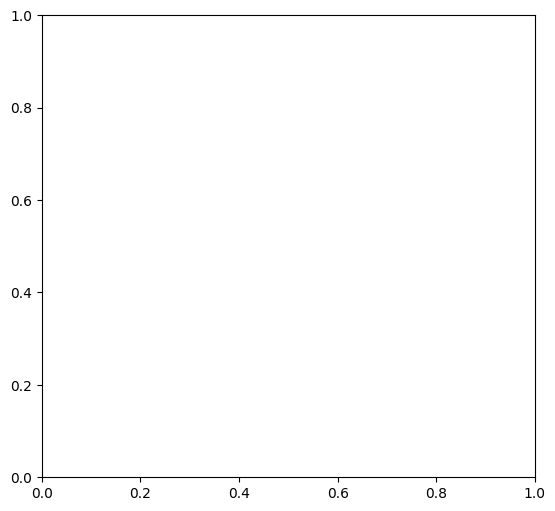

In [30]:
def visualize_model_results_enhanced_3_features(results_df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    plt.style.use('default')
    sns.set_palette("husl")

    fig = plt.figure(figsize=(14, 6))

    BASELINE_COLOR = '#05998c'
    ENHANCED_COLOR = '#f04d23'
    ENHANCED_2_COLOR = '#FFA500'

    results_no_lstm = results_df[results_df['Model'] != 'LSTM'].copy()
    models = ['RF', 'MLP', 'XGB']

    # ==== 1. RР В Р’В Р Р†Р вЂљРІвЂћСћР В Р’В Р Р†Р вЂљР’В  ====
    ax1 = plt.subplot(1, 2, 1)

    baseline_data = results_no_lstm[results_no_lstm['Features'] == 'Baseline'].set_index('Model')['RР В Р’В Р Р†Р вЂљРІвЂћСћР В Р’В Р Р†Р вЂљР’В ']
    enhanced_data = results_no_lstm[results_no_lstm['Features'] == 'Enhanced'].set_index('Model')['RР В Р’В Р Р†Р вЂљРІвЂћСћР В Р’В Р Р†Р вЂљР’В ']
    enhanced_2_data = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2'].set_index('Model')['RР В Р’В Р Р†Р вЂљРІвЂћСћР В Р’В Р Р†Р вЂљР’В ']

    baseline_data = baseline_data.reindex(models, fill_value=0)
    enhanced_data = enhanced_data.reindex(models, fill_value=0)
    enhanced_2_data = enhanced_2_data.reindex(models, fill_value=0)

    x = np.arange(len(models))
    width = 0.25

    bars1 = ax1.bar(x - width, baseline_data.values, width,
                    label='Baseline', alpha=0.85, color=BASELINE_COLOR)
    bars2 = ax1.bar(x, enhanced_data.values, width,
                    label='Enhanced', alpha=0.85, color=ENHANCED_COLOR)
    bars3 = ax1.bar(x + width, enhanced_2_data.values, width,
                    label='Enhanced_2', alpha=0.85, color=ENHANCED_2_COLOR)

    ax1.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax1.set_ylabel('RР В Р’В Р Р†Р вЂљРІвЂћСћР В Р’В Р Р†Р вЂљР’В  Score', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance Comparison\n(RР В Р’В Р Р†Р вЂљРІвЂћСћР В Р’В Р Р†Р вЂљР’В  Score)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, fontsize=11)
    ax1.legend(fontsize=11, loc='lower right')  # <-- here
    ax1.grid(axis='y', alpha=0.3)

    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax1.text(bar.get_x() + bar.get_width()/2., h + 0.005, f'{h:.3f}',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold' if bars == bars3 else 'normal')

    # ==== 2. MAE ====
    ax2 = plt.subplot(1, 2, 2)

    baseline_mae = results_no_lstm[results_no_lstm['Features'] == 'Baseline'].set_index('Model')['MAE']
    enhanced_mae = results_no_lstm[results_no_lstm['Features'] == 'Enhanced'].set_index('Model')['MAE']
    enhanced_2_mae = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2'].set_index('Model')['MAE']

    baseline_mae = baseline_mae.reindex(models, fill_value=0)
    enhanced_mae = enhanced_mae.reindex(models, fill_value=0)
    enhanced_2_mae = enhanced_2_mae.reindex(models, fill_value=0)

    bars4 = ax2.bar(x - width, baseline_mae.values, width,
                    label='Baseline', alpha=0.85, color=BASELINE_COLOR)
    bars5 = ax2.bar(x, enhanced_mae.values, width,
                    label='Enhanced', alpha=0.85, color=ENHANCED_COLOR)
    bars6 = ax2.bar(x + width, enhanced_2_mae.values, width,
                    label='Enhanced_2', alpha=0.85, color=ENHANCED_2_COLOR)

    ax2.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax2.set_ylabel('MAE (kWh/mР В Р’В Р Р†Р вЂљРІвЂћСћР В Р’В Р Р†Р вЂљР’В )', fontsize=12, fontweight='bold')
    ax2.set_title('Model Error Comparison\n(MAE)', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, fontsize=11)
    ax2.legend(fontsize=11, loc='lower right')  # <-- and here
    ax2.grid(axis='y', alpha=0.3)

    for bars in [bars4, bars5, bars6]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax2.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold' if bars == bars6 else 'normal')

    plt.tight_layout(pad=3.0)
    plt.show()
    return fig

fig = visualize_model_results_enhanced_3_features(tuned_results)






enhanced3_all_results loaded OK
tabnet_tabpfn_results loaded OK
tuned_results MLP rows loaded OK (3 rows)

Combined table (24 model-feature combinations):
       Model    Features        R2        MAE
0         RF  Enhanced_3  0.539038  28.835229
1        XGB  Enhanced_3  0.532467  29.572394
2   CatBoost  Enhanced_3  0.526120  30.132362
3     TabNet  Enhanced_3  0.507512  31.029387
4   LightGBM  Enhanced_3  0.502930  30.374631
5   CatBoost    Enhanced  0.497062  31.352817
6   CatBoost  Enhanced_2  0.494334  31.523289
7   LightGBM    Enhanced  0.493493  30.785056
8         RF  Enhanced_2  0.493082  30.371479
9   LightGBM  Enhanced_2  0.491363  31.798992
10       XGB  Enhanced_2  0.488497  30.811207
11        RF    Enhanced  0.480862  30.266006
12  CatBoost    Baseline  0.480086  32.310714
13       XGB    Enhanced  0.478256  30.694297
14       XGB    Baseline  0.472097  32.225095
15    TabNet  Enhanced_2  0.467215  33.704337
16        RF    Baseline  0.461790  31.878803
17  LightGBM    B

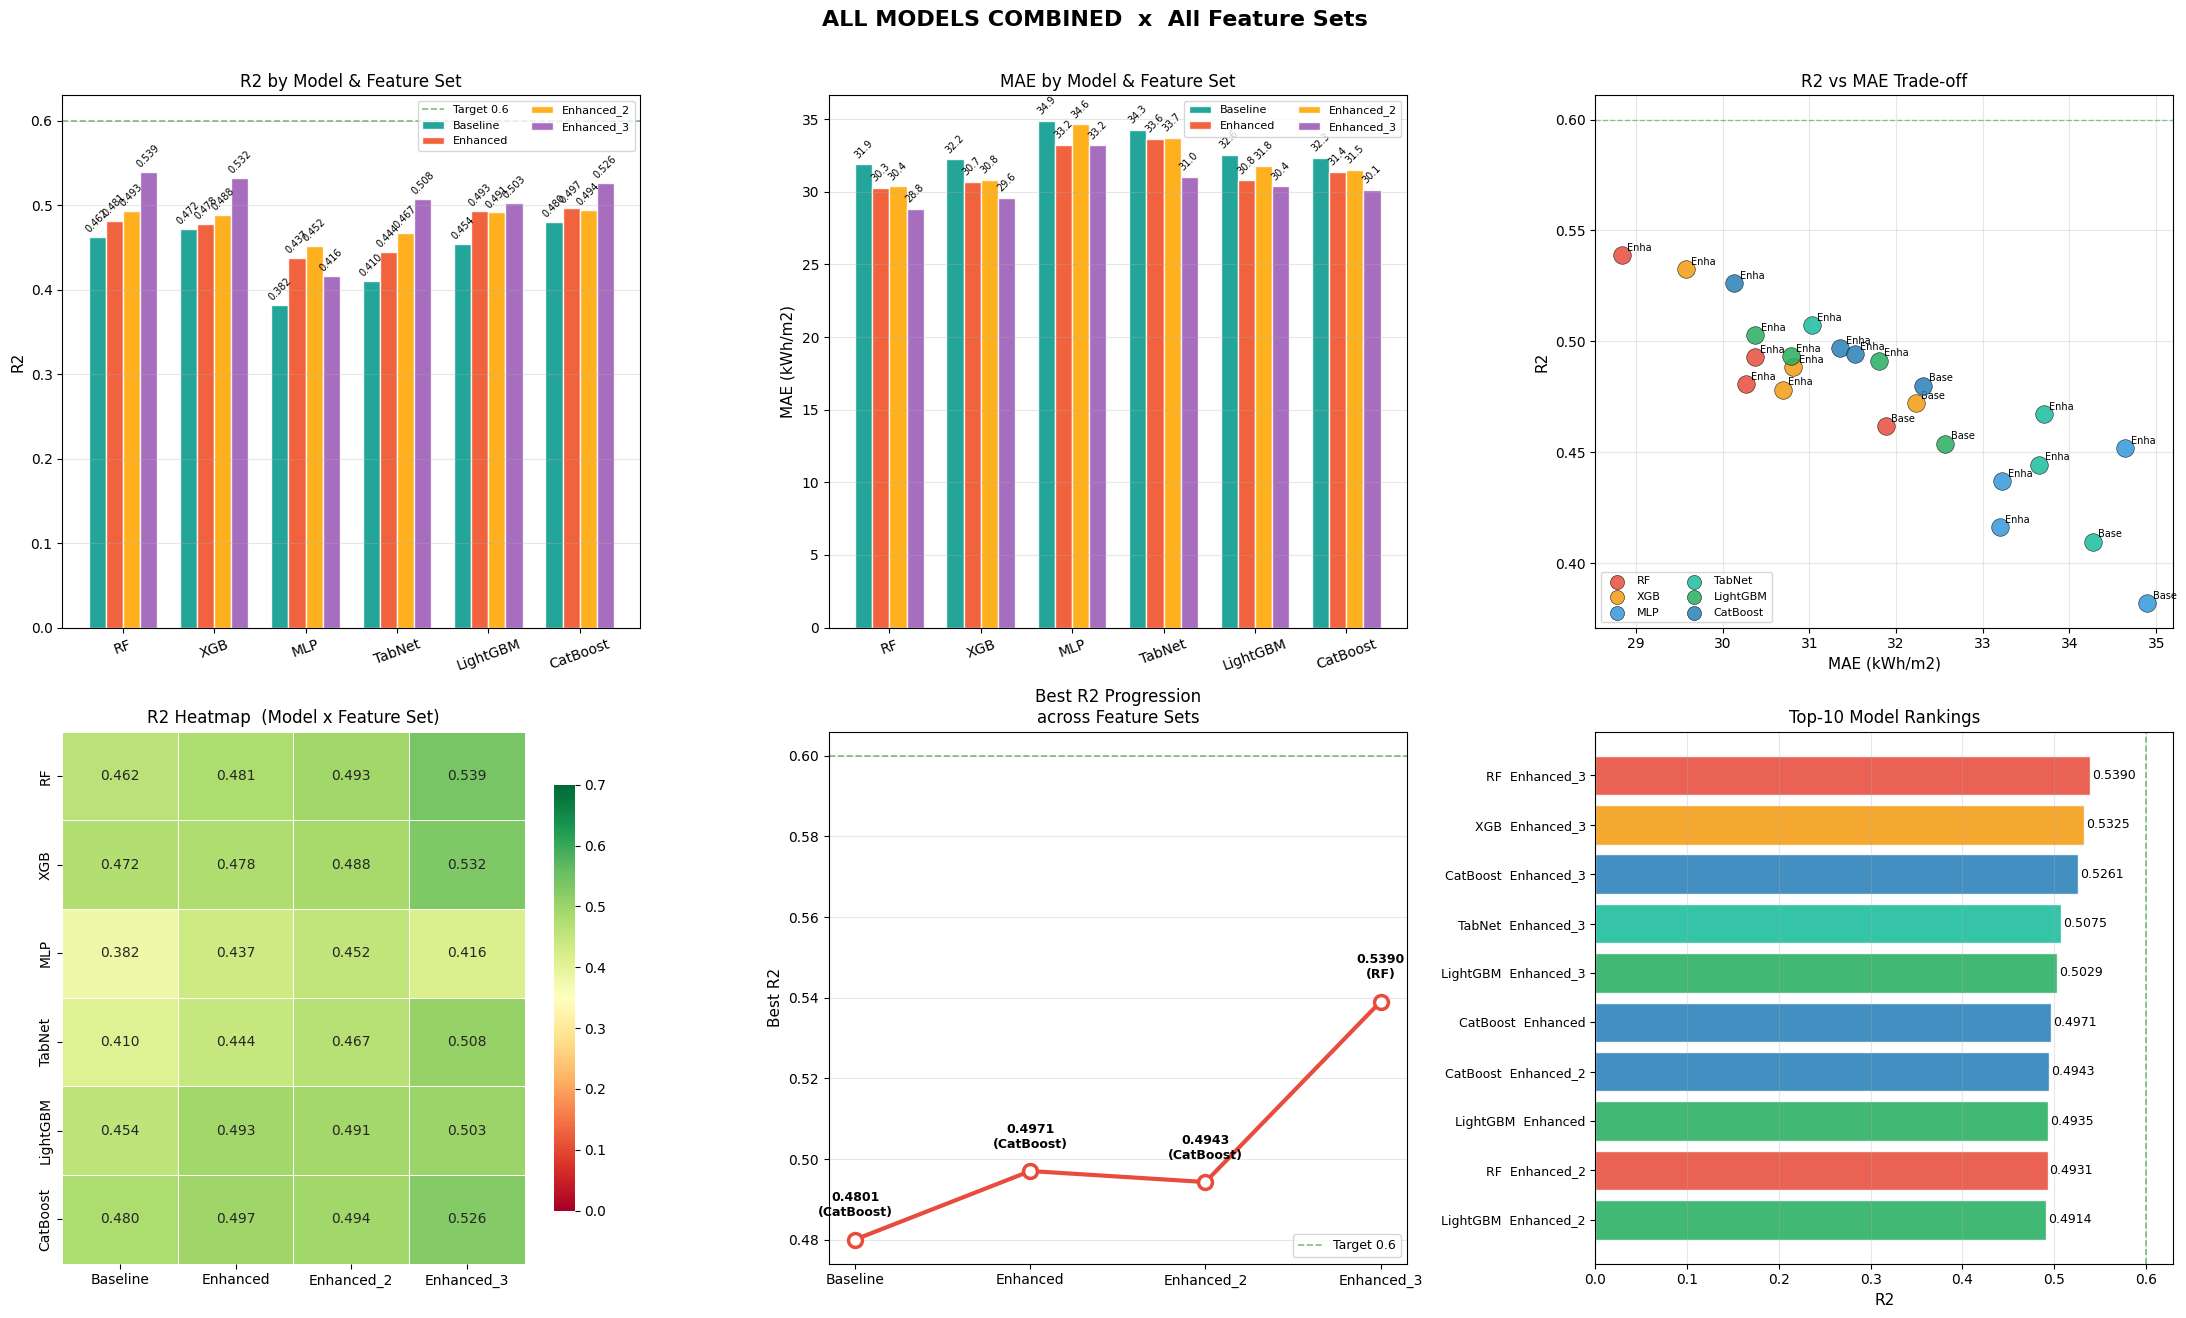

  Saved: viz_ALL_MODELS_COMBINED__x__All_Fe.png


In [31]:
# ============================================================
# Comprehensive visualization for ALL result sets.
# Combines: enhanced3_all_results (RF/XGB/LightGBM/CatBoost x 4 feature sets),
#           tabnet_tabpfn_results (TabNet/TabPFN x feature sets),
#           MLP rows from tuned_results (avoids duplicating RF/XGB rows).
# Run AFTER cells 15, 17, and 19.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import pandas as pd


FEAT_ORDER  = ['Baseline', 'Enhanced', 'Enhanced_2', 'Enhanced_3']
FEAT_COLORS = {
    'Baseline':   '#05998c',
    'Enhanced':   '#f04d23',
    'Enhanced_2': '#FFA500',
    'Enhanced_3': '#9b59b6',
}
MODEL_COLORS = {
    'RF': '#e74c3c', 'XGB': '#f39c12', 'MLP': '#3498db',
    'TabNet': '#1abc9c', 'TabPFN': '#8e44ad',
    'LightGBM': '#27ae60', 'CatBoost': '#2980b9',
}


def _normalise(df):
    """Rename garbled R2 column and keep only needed cols."""
    d = df.copy()
    r2_col = next((c for c in d.columns if c.startswith('R')), None)
    if r2_col and r2_col != 'R2':
        d = d.rename(columns={r2_col: 'R2'})
    for col in ['R2', 'MAE', 'Model', 'Features']:
        if col not in d.columns:
            raise ValueError(f"Column '{col}' missing from results DataFrame")
    return d[['Model', 'Features', 'R2', 'MAE']].copy()


def visualize_results(results_df, title="Model Comparison", target_r2=0.6):
    """6-panel figure: R2 bars | MAE bars | R2xMAE scatter | heatmap | progression | top-10"""
    df = _normalise(results_df)

    models    = sorted(df['Model'].unique(),
                       key=lambda m: list(MODEL_COLORS.keys()).index(m)
                       if m in MODEL_COLORS else 99)
    feat_sets = [f for f in FEAT_ORDER if f in df['Features'].unique()] +   [f for f in df['Features'].unique() if f not in FEAT_ORDER]

    n_f  = len(feat_sets)
    cmap = cm.get_cmap('tab10')
    model_c = {m: MODEL_COLORS.get(m, cmap(i/len(models))) for i, m in enumerate(models)}
    feat_c  = {f: FEAT_COLORS.get(f, cmap(i/n_f))           for i, f in enumerate(feat_sets)}

    fig, axes = plt.subplots(2, 3, figsize=(22, 13))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    width  = min(0.75 / n_f, 0.25)
    x      = np.arange(len(models))

    # 1. R2 grouped bar
    ax = axes[0, 0]
    for i, feat in enumerate(feat_sets):
        sub   = df[df['Features'] == feat].set_index('Model').reindex(models)
        vals  = sub['R2'].fillna(0).values
        off   = (i - n_f/2 + 0.5) * width
        bars  = ax.bar(x + off, vals, width, label=feat,
                       alpha=0.88, color=feat_c[feat], edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 0.05:
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)
    ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10, rotation=20)
    ax.set_ylabel('R2', fontsize=11); ax.set_title('R2 by Model & Feature Set', fontsize=12)
    ax.axhline(target_r2, color='green', lw=1.2, ls='--', alpha=0.5, label=f'Target {target_r2}')
    ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)

    # 2. MAE grouped bar
    ax = axes[0, 1]
    for i, feat in enumerate(feat_sets):
        sub   = df[df['Features'] == feat].set_index('Model').reindex(models)
        vals  = sub['MAE'].fillna(0).values
        off   = (i - n_f/2 + 0.5) * width
        bars  = ax.bar(x + off, vals, width, label=feat,
                       alpha=0.88, color=feat_c[feat], edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 1:
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                        f'{v:.1f}', ha='center', va='bottom', fontsize=7, rotation=45)
    ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10, rotation=20)
    ax.set_ylabel('MAE (kWh/m2)', fontsize=11); ax.set_title('MAE by Model & Feature Set', fontsize=12)
    ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)

    # 3. R2 x MAE scatter
    ax = axes[0, 2]
    for mdl in models:
        sub = df[df['Model'] == mdl]
        for _, row in sub.iterrows():
            ax.scatter(row['MAE'], row['R2'], s=160, alpha=0.85,
                       color=model_c[mdl], edgecolors='black', linewidth=0.4,
                       zorder=3, label=mdl if row.name == sub.index[0] else '')
            ax.annotate(row['Features'][:4], (row['MAE'], row['R2']),
                        xytext=(4, 3), textcoords='offset points', fontsize=7)
    ax.axhline(target_r2, color='green', lw=1, ls='--', alpha=0.4)
    ax.set_xlabel('MAE (kWh/m2)', fontsize=11); ax.set_ylabel('R2', fontsize=11)
    ax.set_title('R2 vs MAE Trade-off', fontsize=12)
    ax.legend(fontsize=8, ncol=2, markerscale=0.8); ax.grid(alpha=0.3)

    # 4. Heatmap R2 (model x feature set)
    ax = axes[1, 0]
    pivot = df.pivot_table(values='R2', index='Model', columns='Features', aggfunc='first')
    pivot = pivot.reindex(index=models,
                          columns=[f for f in FEAT_ORDER if f in pivot.columns] +
                                  [f for f in pivot.columns if f not in FEAT_ORDER])
    sns.heatmap(pivot.fillna(0), annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.0, vmax=max(0.7, df['R2'].max()),
                ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title('R2 Heatmap  (Model x Feature Set)', fontsize=12)
    ax.set_xlabel(''); ax.set_ylabel('')

    # 5. Best R2 progression across feature sets
    ax = axes[1, 1]
    best_vals, best_labels = [], []
    for feat in feat_sets:
        sub = df[df['Features'] == feat]
        if len(sub):
            best_row = sub.loc[sub['R2'].idxmax()]
            best_vals.append(best_row['R2'])
            best_labels.append(str(best_row['Model']))
    ax.plot(feat_sets, best_vals, 'o-', lw=3, ms=10,
            color='#e74c3c', mfc='white', mew=2.5)
    for i, (v, lbl) in enumerate(zip(best_vals, best_labels)):
        ax.text(i, v + 0.005, f'{v:.4f}\n({lbl})',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.axhline(target_r2, color='green', lw=1.2, ls='--', alpha=0.5, label=f'Target {target_r2}')
    ax.set_ylabel('Best R2', fontsize=11)
    ax.set_title('Best R2 Progression\nacross Feature Sets', fontsize=12)
    ax.set_xticks(range(len(feat_sets))); ax.set_xticklabels(feat_sets, fontsize=10)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    # 6. Horizontal top-10 ranking
    ax = axes[1, 2]
    top = df.nlargest(min(10, len(df)), 'R2').iloc[::-1]
    bar_colors = [model_c.get(m, '#888') for m in top['Model']]
    bars = ax.barh(range(len(top)),
                   top['R2'], color=bar_colors, alpha=0.88, edgecolor='white')
    ax.set_yticks(range(len(top)))
    labels_top = [r['Model'] + '  ' + r['Features'] for _, r in top.iterrows()]
    ax.set_yticklabels(labels_top, fontsize=9)
    ax.set_xlabel('R2', fontsize=11); ax.set_title('Top-10 Model Rankings', fontsize=12)
    ax.axvline(target_r2, color='green', lw=1.2, ls='--', alpha=0.5)
    for bar, v in zip(bars, top['R2']):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"viz_{title[:30].replace(' ','_').replace('/','_')}.png",
                dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  Saved: viz_{title[:30].replace(' ','_').replace('/','_')}.png")
    return fig


# ── Combine all available result sets into one DataFrame ─────────────────────
def _combine_results(*dfs):
    parts = []
    for df in dfs:
        try:
            parts.append(_normalise(df))
        except Exception:
            pass
    if not parts:
        raise ValueError('No valid result DataFrames found.')
    combined = pd.concat(parts, ignore_index=True)
    # De-duplicate: keep best R2 per (Model, Features) combination
    combined = (combined.sort_values('R2', ascending=False)
                        .drop_duplicates(subset=['Model', 'Features'])
                        .reset_index(drop=True))
    return combined


# ════════════════════════════════════════════════════════════════════════════
# Combine results:
#   enhanced3_all_results  - RF/XGB/LightGBM/CatBoost across all 4 feature sets
#   tabnet_tabpfn_results   - TabNet/TabPFN across feature sets
#   MLP-only from tuned_results - avoids duplicating RF/XGB rows
# ════════════════════════════════════════════════════════════════════════════
parts = []

# 1. RF / XGB / LightGBM / CatBoost across all 4 feature sets
try:
    parts.append(_normalise(enhanced3_all_results))
    print('enhanced3_all_results loaded OK')
except NameError:
    print('enhanced3_all_results not found - run cell 19 first')

# 2. TabNet / TabPFN across feature sets
try:
    parts.append(_normalise(tabnet_tabpfn_results))
    print('tabnet_tabpfn_results loaded OK')
except NameError:
    print('tabnet_tabpfn_results not found - run cell 17 first')

# 3. MLP rows only from tuned_results (RF/XGB already covered by enhanced3_all_results)
try:
    tr_norm = _normalise(tuned_results)
    mlp_rows = tr_norm[tr_norm['Model'] == 'MLP']
    if len(mlp_rows):
        parts.append(mlp_rows)
        print(f'tuned_results MLP rows loaded OK ({len(mlp_rows)} rows)')
except NameError:
    print('tuned_results not found - run cell 15 first')

if parts:
    combined_all = _combine_results(*parts)
    print(f'\nCombined table ({len(combined_all)} model-feature combinations):')
    print(combined_all.sort_values('R2', ascending=False).reset_index(drop=True).to_string())
    print()
    visualize_results(combined_all, 'ALL MODELS COMBINED  x  All Feature Sets')
else:
    print('No results available - run cells 15, 17 and 19 first')

## Feature Analysis, Subtype & PCA

Separate analysis section exploring feature importance, PCA decomposition, and building subtype clustering.

No transformation needed (skewness: 0.56)
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
  floor_count from 'c2025_flrcount'
  Enhanced_3: 33 features


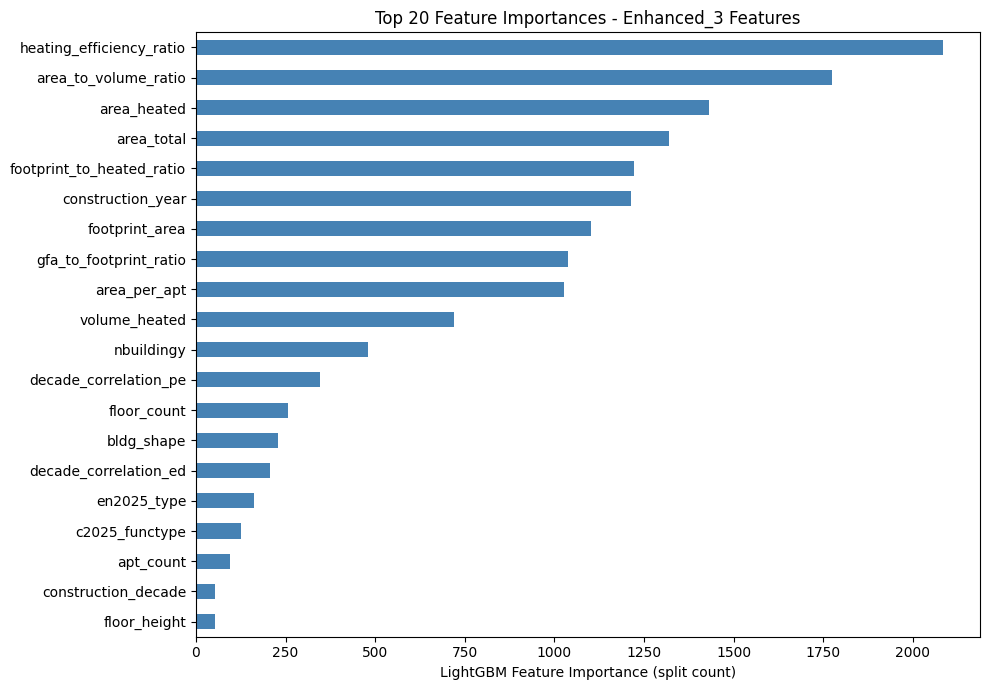


Top features:
  heating_efficiency_ratio            2083
  area_to_volume_ratio                1773
  area_heated                         1430
  area_total                          1320
  footprint_to_heated_ratio           1222
  construction_year                   1213
  footprint_area                      1102
  gfa_to_footprint_ratio              1039
  area_per_apt                        1026
  volume_heated                       721
  nbuildingy                          480
  decade_correlation_pe               347
  floor_count                         257
  bldg_shape                          228
  decade_correlation_ed               207
  en2025_type                         161
  c2025_functype                      126
  apt_count                           96
  construction_decade                 53
  floor_height                        52
No transformation needed (skewness: 0.56)
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total:

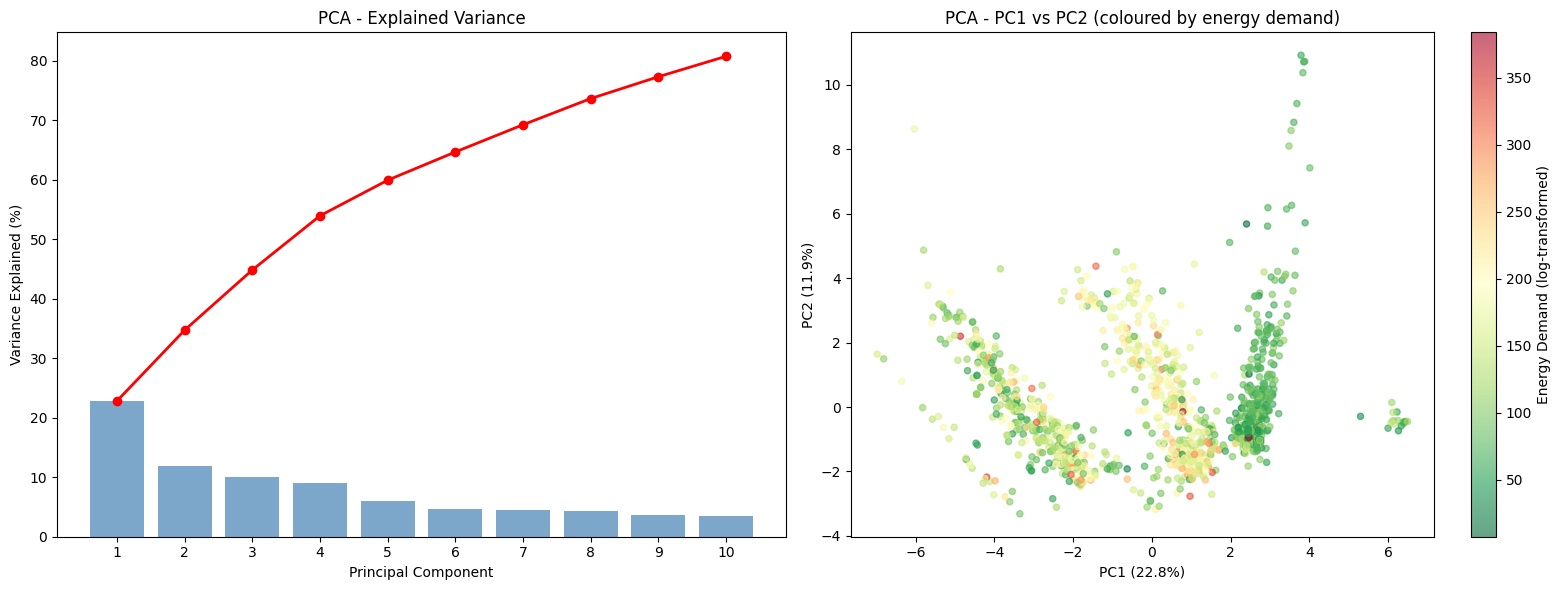


PCA Summary (10 components):
  PC1: 22.8%  (cumulative: 22.8%)
  PC2: 11.9%  (cumulative: 34.7%)
  PC3: 10.1%  (cumulative: 44.9%)
  PC4: 9.1%  (cumulative: 54.0%)
  PC5: 6.0%  (cumulative: 59.9%)
  PC6: 4.7%  (cumulative: 64.7%)
  PC7: 4.6%  (cumulative: 69.3%)
  PC8: 4.4%  (cumulative: 73.7%)
  PC9: 3.7%  (cumulative: 77.3%)
  PC10: 3.4%  (cumulative: 80.8%)
No transformation needed (skewness: 0.56)
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
  floor_count from 'c2025_flrcount'
  Enhanced_3: 33 features


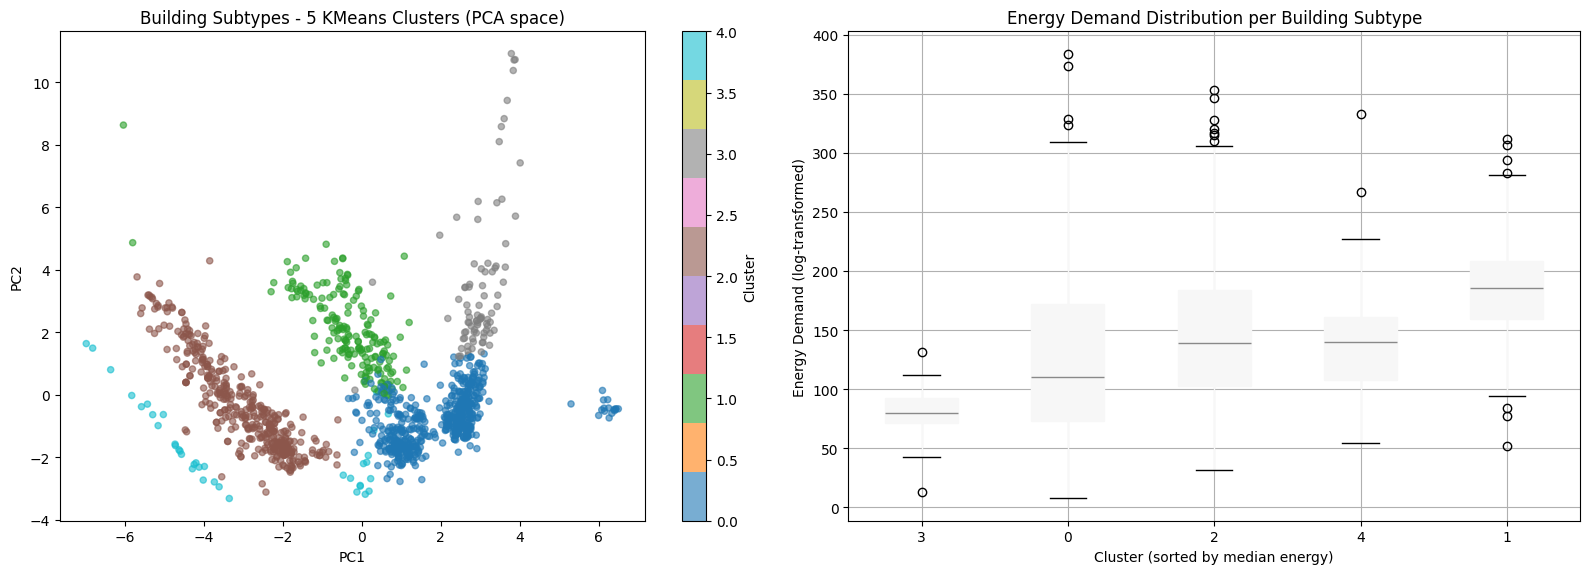


Cluster Summary:
Cluster    Count    Median Energy    Mean Energy
  3          84       79.994          81.077
  0          567      110.400          127.644
  2          405      139.000          146.849
  4          37       140.000          141.622
  1          184      185.817          183.116


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 1. FEATURE IMPORTANCE (LightGBM on Enhanced_3) ──────────────────────────
def plot_feature_importance(df, target_column='en2025_enegy_demand_present_m2', top_n=20):
    """Plot top-N feature importances from LightGBM trained on Enhanced_3 features."""
    try:
        import lightgbm as lgb
    except ImportError:
        print('lightgbm not installed'); return

    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    try:
        _ = DECADE_CORRELATIONS_PE
    except NameError:
        DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df)

    df_clean, _, target_transformed, _ = prepare_target_data(df, target_column)

    # Leakage-free train mask
    n = len(df_clean)
    idx_tr, _ = train_test_split(np.arange(n), test_size=0.2, random_state=42)
    train_mask = pd.Series(False, index=df_clean.index)
    train_mask.iloc[idx_tr] = True

    X = create_enhanced_3_features(df_clean, target_column, train_mask=train_mask)
    from sklearn.preprocessing import LabelEncoder
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

    X_tr = X.iloc[idx_tr]
    y_tr = target_transformed.iloc[idx_tr]

    model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
    model.fit(X_tr, y_tr)

    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 7))
    imp[::-1].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('LightGBM Feature Importance (split count)')
    ax.set_title(f'Top {top_n} Feature Importances - Enhanced_3 Features')
    plt.tight_layout()
    plt.show()
    print('\nTop features:')
    for feat, val in imp.items():
        print(f'  {feat:<35} {val:.0f}')
    return imp

importance = plot_feature_importance(overlapping_gdf_dataset)


# ── 2. PCA of Feature Space ──────────────────────────────────────────────────
def plot_pca_feature_space(df, target_column='en2025_enegy_demand_present_m2', n_components=10):
    """PCA decomposition of Enhanced_3 features coloured by target energy demand."""
    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    try:
        _ = DECADE_CORRELATIONS_PE
    except NameError:
        DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df)

    df_clean, _, target_transformed, _ = prepare_target_data(df, target_column)
    n = len(df_clean)
    idx_tr, _ = train_test_split(np.arange(n), test_size=0.2, random_state=42)
    train_mask = pd.Series(False, index=df_clean.index)
    train_mask.iloc[idx_tr] = True

    X = create_enhanced_3_features(df_clean, target_column, train_mask=train_mask)
    from sklearn.preprocessing import LabelEncoder
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=min(n_components, X.shape[1]))
    X_pca = pca.fit_transform(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Panel 1: Explained variance
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
    axes[0].bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_ * 100, color='steelblue', alpha=0.7)
    axes[0].plot(range(1, len(cumvar)+1), cumvar, 'ro-', linewidth=2)
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Variance Explained (%)')
    axes[0].set_title('PCA - Explained Variance')
    axes[0].set_xticks(range(1, len(cumvar)+1))

    # Panel 2: PC1 vs PC2 coloured by energy demand
    sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                         c=target_transformed.values, cmap='RdYlGn_r',
                         alpha=0.6, s=20)
    plt.colorbar(sc, ax=axes[1], label='Energy Demand (log-transformed)')
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[1].set_title('PCA - PC1 vs PC2 (coloured by energy demand)')

    plt.tight_layout()
    plt.show()

    print(f'\nPCA Summary ({n_components} components):')
    for i, r in enumerate(pca.explained_variance_ratio_):
        print(f'  PC{i+1}: {r*100:.1f}%  (cumulative: {cumvar[i]:.1f}%)')
    return pca, X_pca

pca_model, X_pca = plot_pca_feature_space(overlapping_gdf_dataset)


# ── 3. BUILDING SUBTYPE CLUSTERING ──────────────────────────────────────────
def plot_building_subtypes(df, target_column='en2025_enegy_demand_present_m2', n_clusters=5):
    """KMeans clustering of buildings in PCA space with energy demand analysis per cluster."""
    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    try:
        _ = DECADE_CORRELATIONS_PE
    except NameError:
        DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df)

    df_clean, _, target_transformed, _ = prepare_target_data(df, target_column)
    n = len(df_clean)
    idx_tr, _ = train_test_split(np.arange(n), test_size=0.2, random_state=42)
    train_mask = pd.Series(False, index=df_clean.index)
    train_mask.iloc[idx_tr] = True

    X = create_enhanced_3_features(df_clean, target_column, train_mask=train_mask)
    from sklearn.preprocessing import LabelEncoder
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=5, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Panel 1: Clusters in PCA space
    scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.6, s=20)
    plt.colorbar(scatter, ax=axes[0], label='Cluster')
    axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
    axes[0].set_title(f'Building Subtypes - {n_clusters} KMeans Clusters (PCA space)')

    # Panel 2: Energy demand distribution per cluster
    cluster_df = pd.DataFrame({'cluster': labels, 'energy': target_transformed.values})
    cluster_order = cluster_df.groupby('cluster')['energy'].median().sort_values().index
    cluster_df['cluster'] = pd.Categorical(cluster_df['cluster'], categories=cluster_order, ordered=True)
    cluster_df.boxplot(column='energy', by='cluster', ax=axes[1], patch_artist=True)
    axes[1].set_xlabel('Cluster (sorted by median energy)')
    axes[1].set_ylabel('Energy Demand (log-transformed)')
    axes[1].set_title('Energy Demand Distribution per Building Subtype')
    plt.suptitle('')

    plt.tight_layout()
    plt.show()

    print('\nCluster Summary:')
    print(f"{'Cluster':<10} {'Count':<8} {'Median Energy':<16} {'Mean Energy'}")
    for c in cluster_order:
        subset = cluster_df[cluster_df['cluster'] == c]['energy']
        print(f"  {c:<8}   {len(subset):<8} {subset.median():.3f}          {subset.mean():.3f}")
    return labels

cluster_labels = plot_building_subtypes(overlapping_gdf_dataset, n_clusters=5)

No transformation needed (skewness: 0.56)
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
  floor_count from 'c2025_flrcount'
  Enhanced_3: 33 features
  PCA COMPONENT LOADINGS -- what each component represents
Loading close to +1 / -1: feature strongly defines this component.
Sign = direction only (positive / negative correlation with PC).

────────────────────────────────────────────────────────────────────────
  PC1 (22.8%)
────────────────────────────────────────────────────────────────────────
  Feature                              Loading  What it means
  ------------------------------------------------------------
  building_category                     +0.338  (+) higher value -> higher PC score
  en2025_type                           -0.331  (-) higher value -> lower  PC score
  Correlation_PM                        +0.319  (+) higher value 

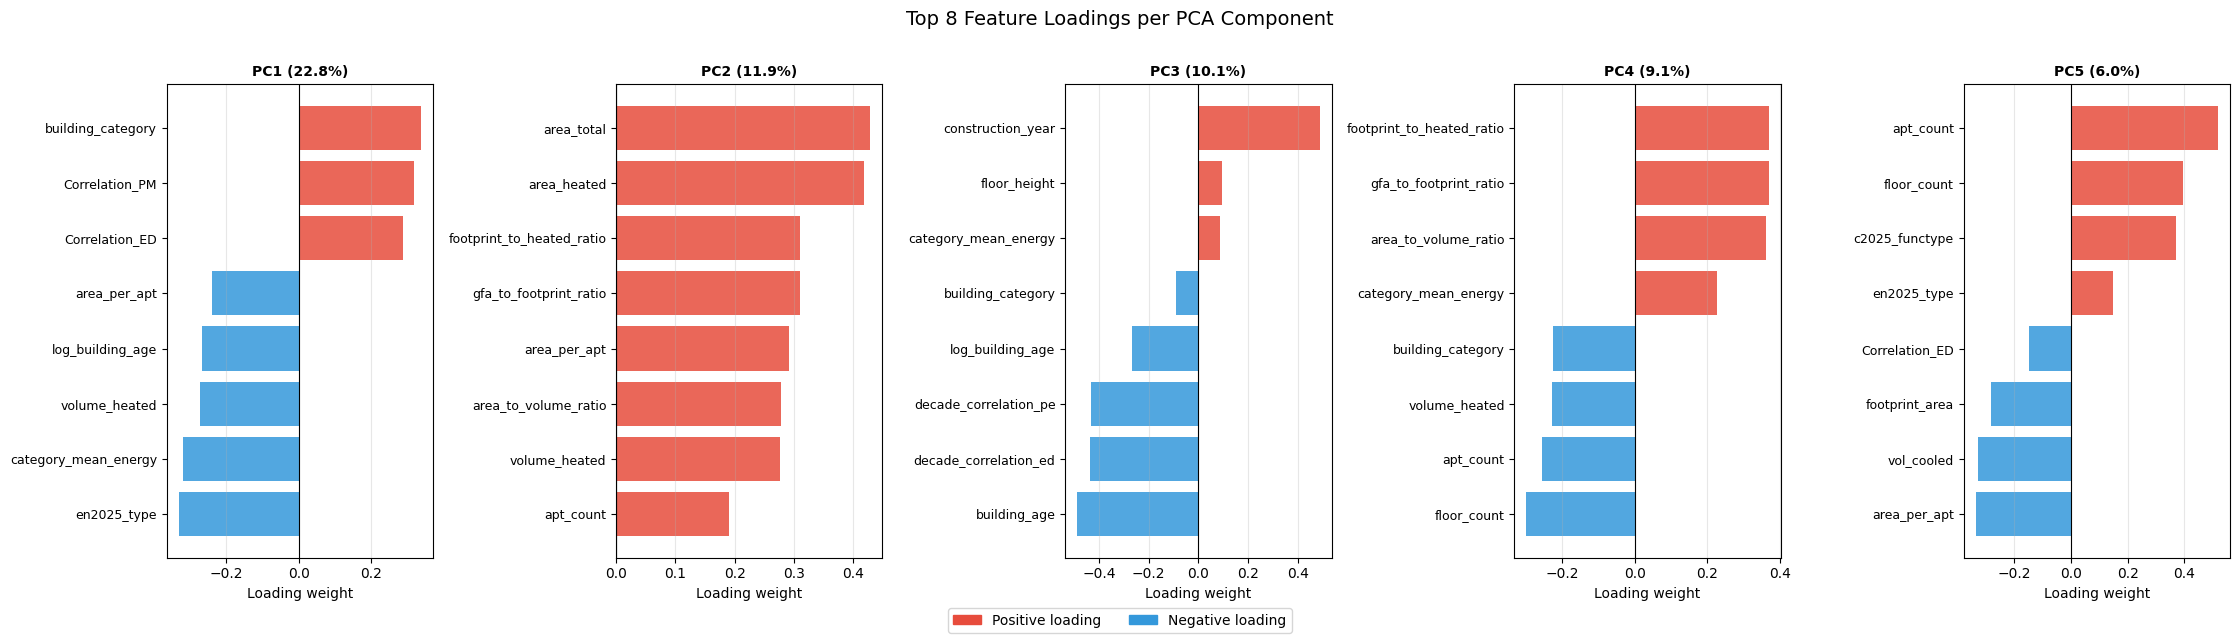

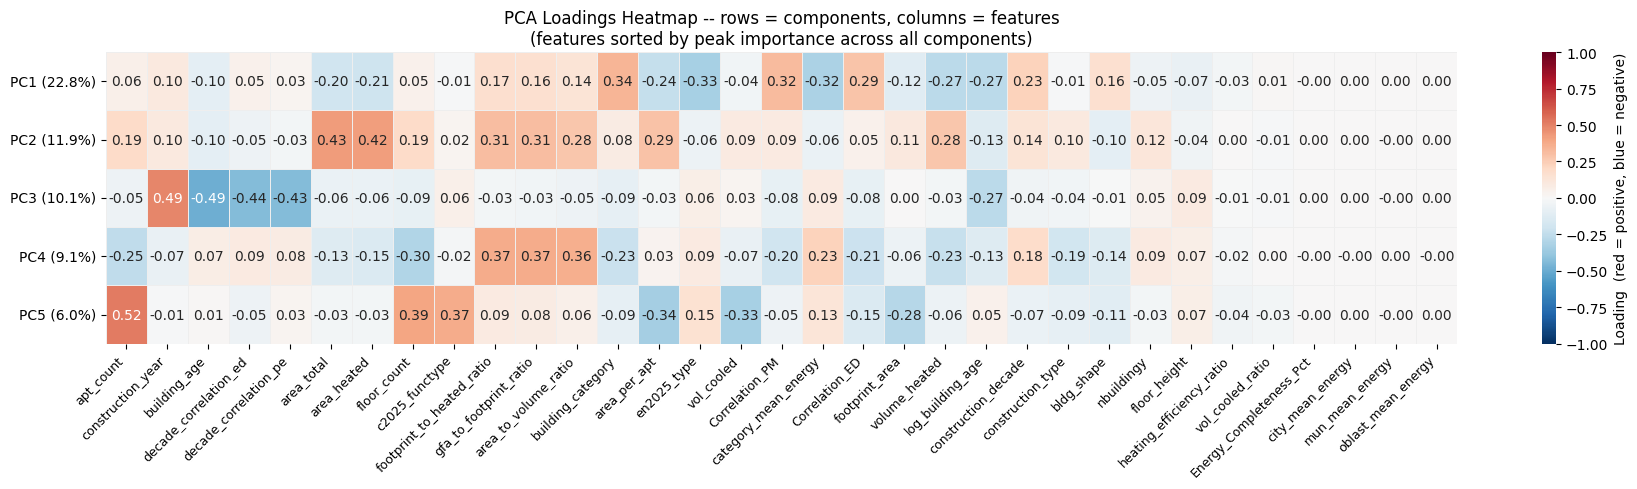

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


def plot_pca_loadings(df, target_column='en2025_enegy_demand_present_m2',
                      n_components=5, top_n=8):
    """
    Show which original features drive each PCA component (loadings).

    A loading close to +1 or -1 means that feature strongly defines the
    component.  Sign indicates direction only, not good vs bad.

    Outputs:
      1. Printed table -- top features per component
      2. Horizontal bar charts -- one per component
      3. Full heatmap -- all features x all components
    """
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.decomposition import PCA

    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    try:
        _ = DECADE_CORRELATIONS_PE
    except NameError:
        DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df)

    df_clean, _, target_transformed, _ = prepare_target_data(df, target_column)
    n = len(df_clean)
    idx_tr, _ = train_test_split(np.arange(n), test_size=0.2, random_state=42)
    train_mask = pd.Series(False, index=df_clean.index)
    train_mask.iloc[idx_tr] = True

    X = create_enhanced_3_features(df_clean, target_column, train_mask=train_mask)
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
    feature_names = list(X.columns)

    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(X_scaled)

    pc_labels = [
        'PC{} ({:.1f}%)'.format(i + 1, pca.explained_variance_ratio_[i] * 100)
        for i in range(n_components)
    ]
    loadings = pd.DataFrame(pca.components_, index=pc_labels, columns=feature_names)

    # -- Printed table --------------------------------------------------------
    SEP = chr(9472) * 72
    print('=' * 72)
    print('  PCA COMPONENT LOADINGS -- what each component represents')
    print('=' * 72)
    print('Loading close to +1 / -1: feature strongly defines this component.')
    print('Sign = direction only (positive / negative correlation with PC).\n')

    for pc_label, row in loadings.iterrows():
        top_feats = row.abs().sort_values(ascending=False).head(top_n).index
        print(SEP)
        print('  ' + pc_label)
        print(SEP)
        print('  {:<35} {:>8}  {}'.format('Feature', 'Loading', 'What it means'))
        print('  ' + '-' * 60)
        for feat in top_feats:
            val = row[feat]
            meaning = '(+) higher value -> higher PC score' if val > 0 \
                      else '(-) higher value -> lower  PC score'
            print('  {:<35} {:>+8.3f}  {}'.format(feat, val, meaning))
        print()

    # -- Bar charts: one per component ----------------------------------------
    fig, axes = plt.subplots(1, n_components,
                             figsize=(4.5 * n_components, 6),
                             sharey=False)
    if n_components == 1:
        axes = [axes]

    for ax, (pc_label, row) in zip(axes, loadings.iterrows()):
        top_vals = row[row.abs().sort_values(ascending=False).head(top_n).index].sort_values()
        bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_vals]
        ax.barh(range(len(top_vals)), top_vals.values, color=bar_colors, alpha=0.85)
        ax.set_yticks(range(len(top_vals)))
        ax.set_yticklabels(top_vals.index, fontsize=9)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Loading weight', fontsize=10)
        ax.set_title(pc_label, fontsize=10, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

    red_patch  = plt.matplotlib.patches.Patch(color='#e74c3c', label='Positive loading')
    blue_patch = plt.matplotlib.patches.Patch(color='#3498db', label='Negative loading')
    fig.legend(handles=[red_patch, blue_patch], loc='lower center',
               ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04))
    plt.suptitle('Top {} Feature Loadings per PCA Component'.format(top_n),
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # -- Heatmap: all features x all components --------------------------------
    feat_order = loadings.abs().max(axis=0).sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(max(14, len(feat_order) * 0.55),
                                    max(4, n_components * 1.0)))
    sns.heatmap(
        loadings[feat_order],
        annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.4, linecolor='#eee',
        cbar_kws={'label': 'Loading  (red = positive, blue = negative)'},
        ax=ax
    )
    ax.set_title(
        'PCA Loadings Heatmap -- rows = components, columns = features\n'
        '(features sorted by peak importance across all components)',
        fontsize=12
    )
    ax.set_ylabel('')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()

    return loadings


pca_loadings = plot_pca_loadings(overlapping_gdf_dataset, n_components=5, top_n=8)


## Model Explanation: SHAP Values & Partial Dependence Plots

### SHAP Values (SHapley Additive exPlanations)

SHAP values quantify each feature's contribution to a specific prediction. Grounded in game theory, they answer: *how much did this feature push the prediction above or below the average?*

| Plot | What it shows |
|---|---|
| **Beeswarm** | Every dot = one test building. X-position = SHAP value (impact on prediction). Colour = feature value (red=high, blue=low). |
| **Bar chart** | Mean absolute SHAP value per feature -- classic global importance. |
| **Dependence** | How one feature's SHAP value changes as the feature value changes. Colour = most-interacting feature. |
| **Waterfall** | Step-by-step feature contributions for the single best and single worst predicted building. |

### Partial Dependence Plots (PDP)

PDPs show the *average* model prediction as one feature varies, with all other features held at their mean. They reveal the global shape of the relationship (linear, non-linear, saturation effects) in real kWh/m2 units.

Red tick marks at the bottom of each panel show the actual distribution of that feature in the training data, so you can distinguish regions with good coverage from extrapolated regions.

> **Model used:** XGBoost on Enhanced_3 features (best-performing model).
> Requires shap for SHAP section:  pip install shap

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Check for shap
SHAP_AVAILABLE = False
try:
    import shap
    SHAP_AVAILABLE = True
    print('shap loaded OK')
except ImportError:
    print('shap not installed -> run:  pip install shap')
    print('PDP analysis will still run.')


def _build_enhanced3(df, target_column):
    from sklearn.preprocessing import LabelEncoder
    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    try:
        _ = DECADE_CORRELATIONS_PE
    except NameError:
        DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = \
            create_correlation_dictionaries(df)

    df_clean, raw_target, target_transformed, use_log = \
        prepare_target_data(df, target_column)
    n = len(df_clean)
    idx_tr, idx_te = train_test_split(np.arange(n), test_size=0.2, random_state=42)
    train_mask = pd.Series(False, index=df_clean.index)
    train_mask.iloc[idx_tr] = True

    X = create_enhanced_3_features(df_clean, target_column, train_mask=train_mask)
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

    return (X, target_transformed, use_log, idx_tr, idx_te,
            list(X.columns), df_clean, raw_target)

shap loaded OK


No transformation needed (skewness: 0.56)
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
  floor_count from 'c2025_flrcount'
  Enhanced_3: 33 features
Training XGBoost... done
Computing SHAP values... done

[Plot 1/4] SHAP Beeswarm


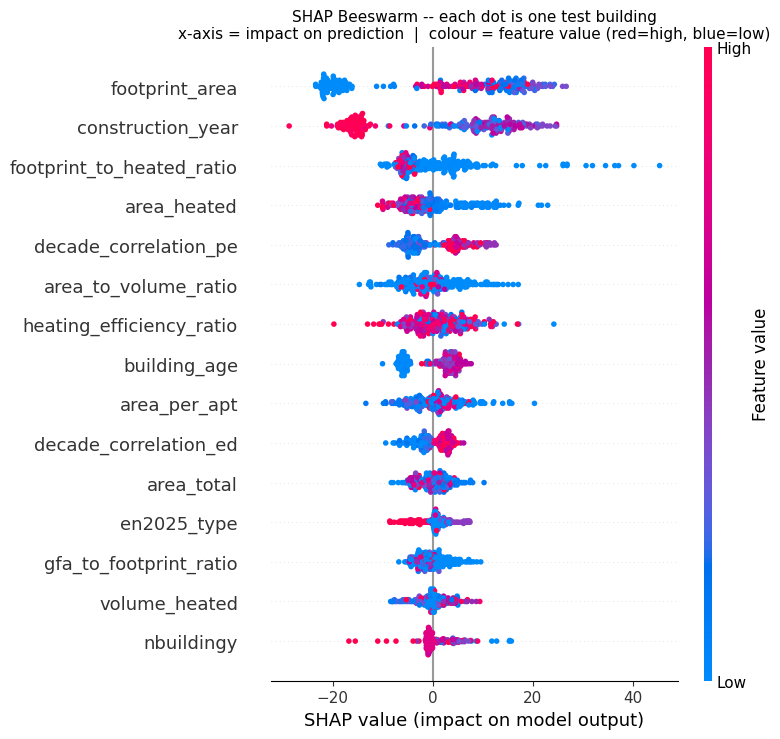

[Plot 2/4] Mean |SHAP| bar


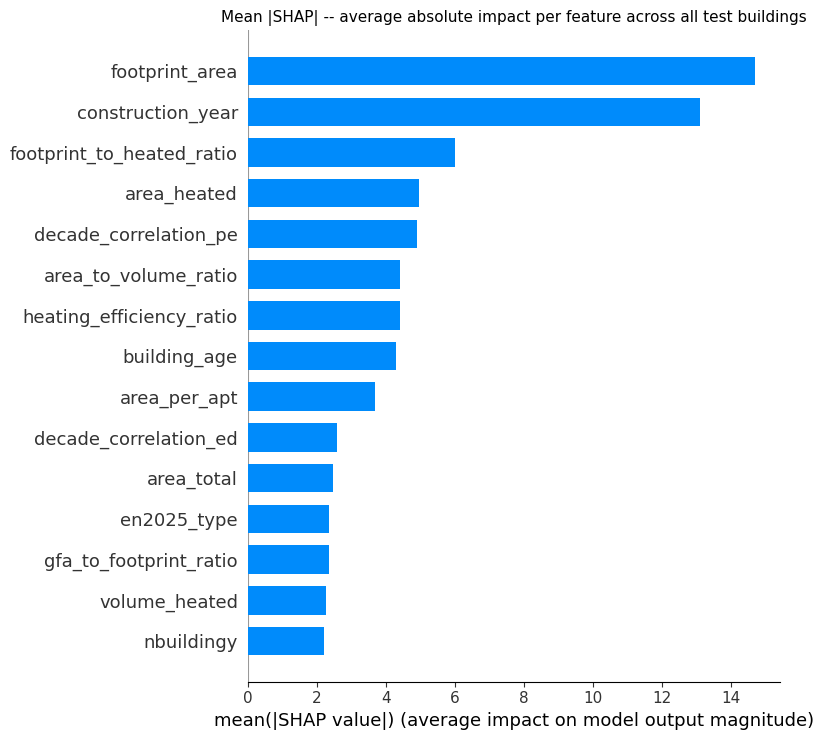

[Plot 3/4] SHAP dependence plots


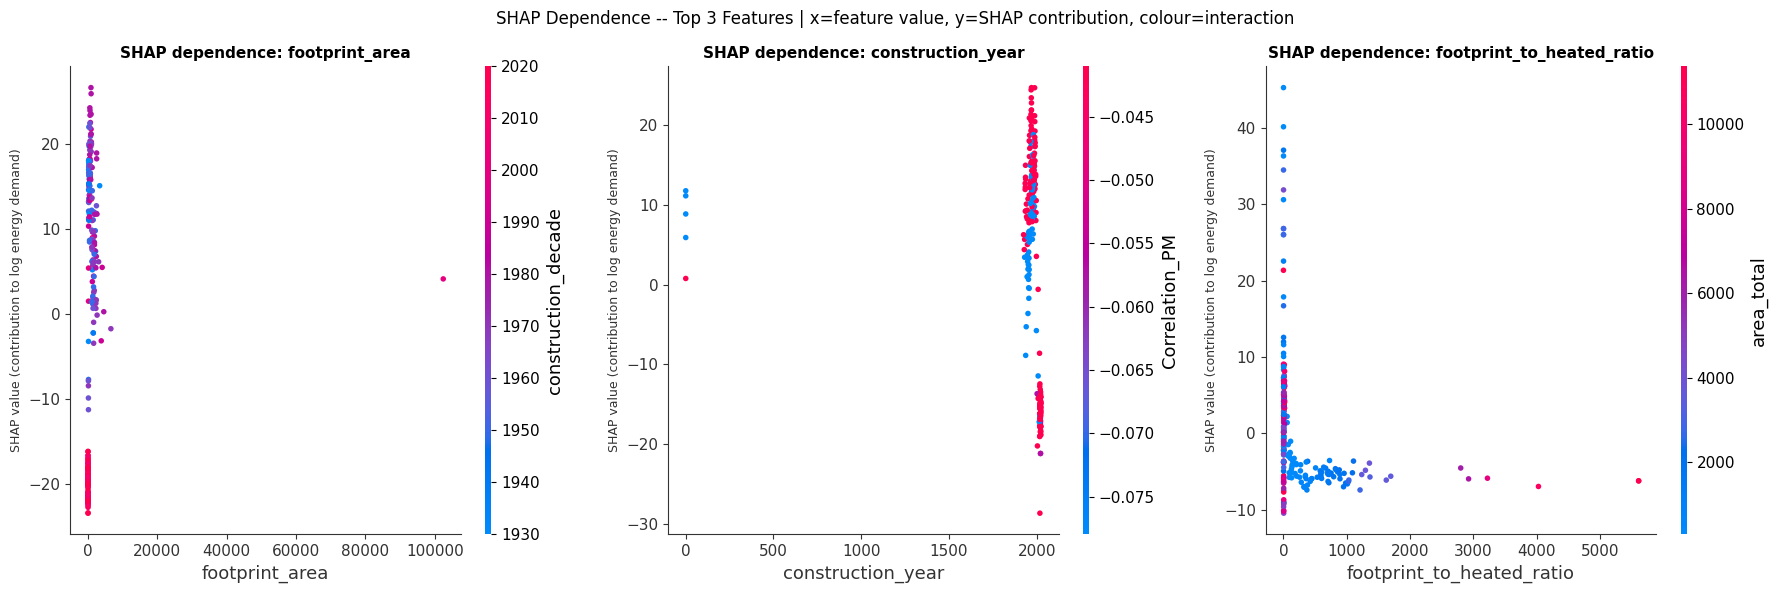

[Plot 4/4] Waterfall plots
  Best  building (error = 0.2 kWh/m2)


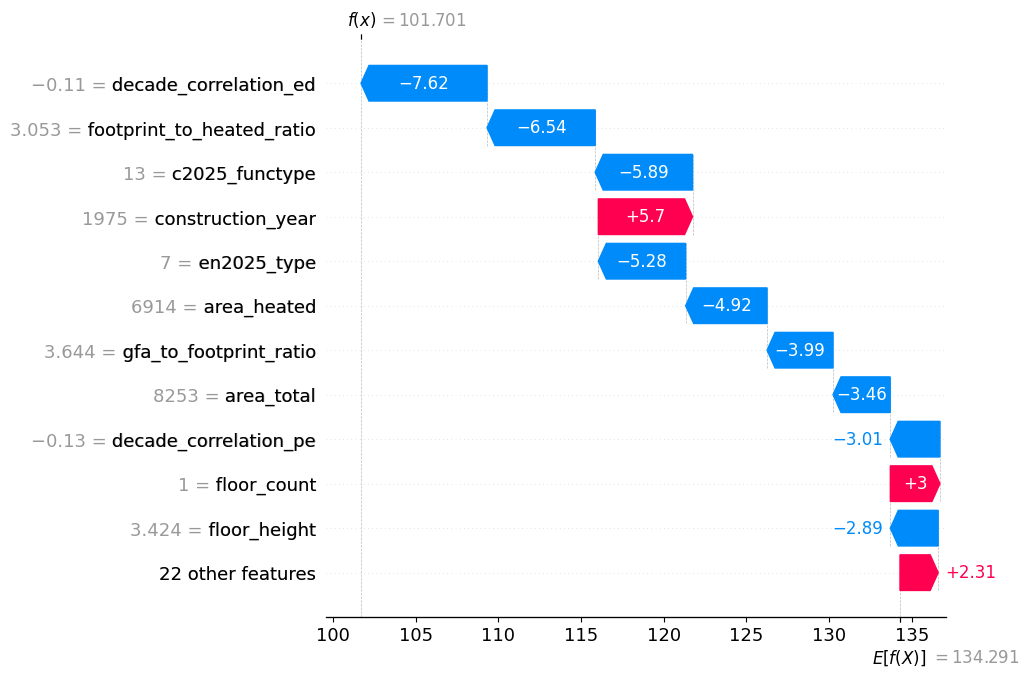

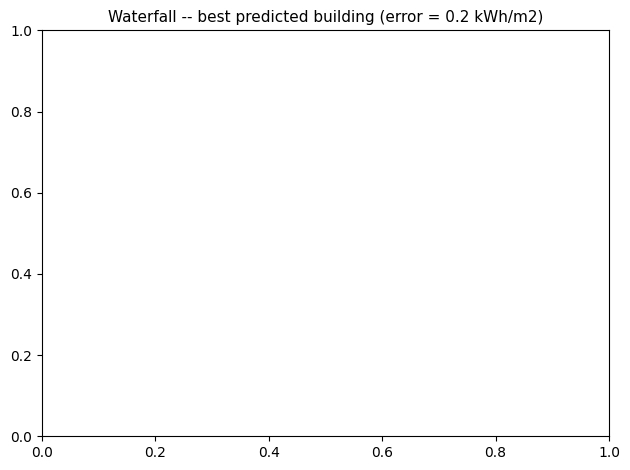

  Worst building (error = 226.4 kWh/m2)


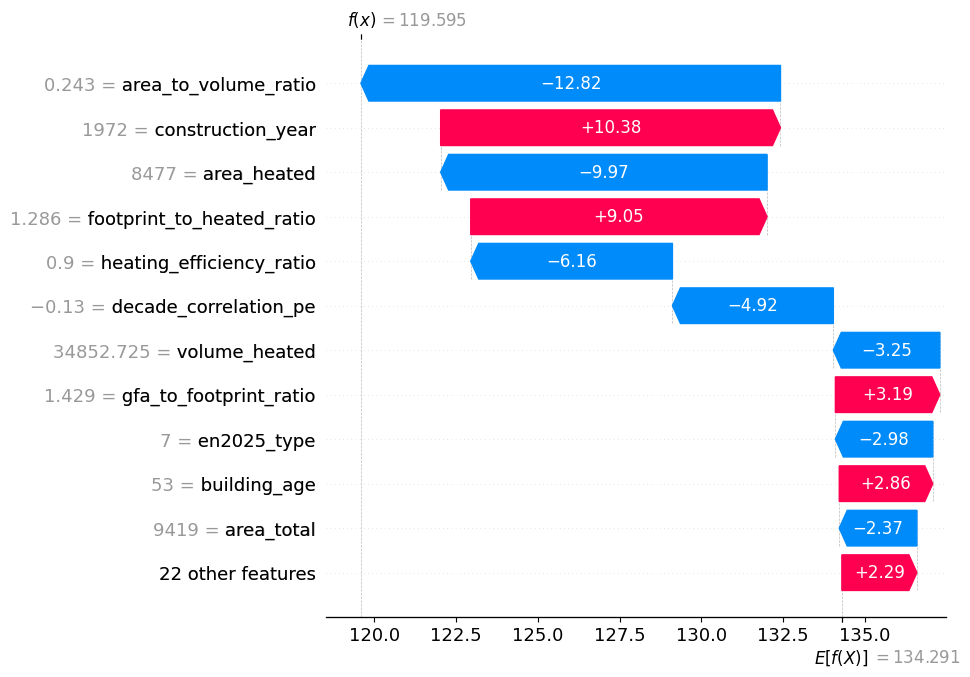

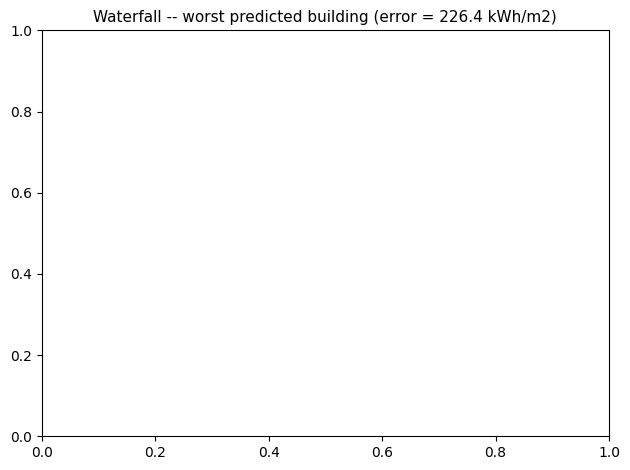

In [35]:
def run_shap_analysis(df, target_column='en2025_enegy_demand_present_m2', top_n=15):
    if not SHAP_AVAILABLE:
        print('Install shap first:  pip install shap'); return None, None

    import xgboost as xgb

    X, y_t, use_log, idx_tr, idx_te, feat_names, df_clean, raw_target = \
        _build_enhanced3(df, target_column)
    X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
    y_tr, y_te = y_t.iloc[idx_tr], y_t.iloc[idx_te]

    print('Training XGBoost...', end=' ', flush=True)
    model = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    )
    model.fit(X_tr, y_tr)
    print('done')

    print('Computing SHAP values...', end=' ', flush=True)
    try:
        explainer = shap.Explainer(model, X_tr)
        shap_exp  = explainer(X_te)
        shap_arr  = shap_exp.values
        base_val  = float(np.mean(shap_exp.base_values))
    except Exception:
        explainer = shap.TreeExplainer(model)
        shap_arr  = explainer.shap_values(X_te)
        base_val  = float(explainer.expected_value)
        shap_exp  = shap.Explanation(
            values=shap_arr,
            base_values=np.full(len(X_te), base_val),
            data=X_te.values,
            feature_names=feat_names
        )
    print('done')

    # Plot 1: Beeswarm
    print('\n[Plot 1/4] SHAP Beeswarm')
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_arr, X_te, feature_names=feat_names, max_display=top_n, show=False)
    plt.title('SHAP Beeswarm -- each dot is one test building\n'
              'x-axis = impact on prediction  |  colour = feature value (red=high, blue=low)', fontsize=11)
    plt.tight_layout(); plt.show()

    # Plot 2: Mean |SHAP| bar
    print('[Plot 2/4] Mean |SHAP| bar')
    plt.figure(figsize=(9, 6))
    shap.summary_plot(shap_arr, X_te, feature_names=feat_names, plot_type='bar', max_display=top_n, show=False)
    plt.title('Mean |SHAP| -- average absolute impact per feature across all test buildings', fontsize=11)
    plt.tight_layout(); plt.show()

    # Plot 3: Dependence plots for top 3 features
    print('[Plot 3/4] SHAP dependence plots')
    mean_abs = pd.Series(np.abs(shap_arr).mean(axis=0), index=feat_names)
    top3 = mean_abs.sort_values(ascending=False).head(3).index.tolist()
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, feat in zip(axes, top3):
        shap.dependence_plot(feat, shap_arr, X_te, feature_names=feat_names, ax=ax, show=False)
        ax.set_title('SHAP dependence: ' + feat, fontsize=11, fontweight='bold')
        ax.set_ylabel('SHAP value (contribution to log energy demand)', fontsize=9)
    plt.suptitle('SHAP Dependence -- Top 3 Features | x=feature value, y=SHAP contribution, colour=interaction', fontsize=12)
    plt.tight_layout(); plt.show()

    # Plot 4: Waterfall
    print('[Plot 4/4] Waterfall plots')
    pred_te    = model.predict(X_te)
    abs_errors = np.abs(y_te.values - pred_te)
    best_idx   = int(np.argmin(abs_errors))
    worst_idx  = int(np.argmax(abs_errors))
    best_err   = float(np.expm1(abs_errors[best_idx]))  if use_log else abs_errors[best_idx]
    worst_err  = float(np.expm1(abs_errors[worst_idx])) if use_log else abs_errors[worst_idx]

    print('  Best  building (error = {:.1f} kWh/m2)'.format(best_err))
    shap.waterfall_plot(shap_exp[best_idx], max_display=12)
    plt.title('Waterfall -- best predicted building (error = {:.1f} kWh/m2)'.format(best_err), fontsize=11)
    plt.tight_layout(); plt.show()

    print('  Worst building (error = {:.1f} kWh/m2)'.format(worst_err))
    shap.waterfall_plot(shap_exp[worst_idx], max_display=12)
    plt.title('Waterfall -- worst predicted building (error = {:.1f} kWh/m2)'.format(worst_err), fontsize=11)
    plt.tight_layout(); plt.show()

    return model, shap_exp


# Run SHAP analysis
xgb_model, shap_explanation = run_shap_analysis(overlapping_gdf_dataset, top_n=15)

No transformation needed (skewness: 0.56)
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
  floor_count from 'c2025_flrcount'
  Enhanced_3: 33 features
Training XGBoost... done
PDP features: ['footprint_area', 'construction_year', 'footprint_to_heated_ratio', 'decade_correlation_pe', 'heating_efficiency_ratio', 'area_to_volume_ratio']


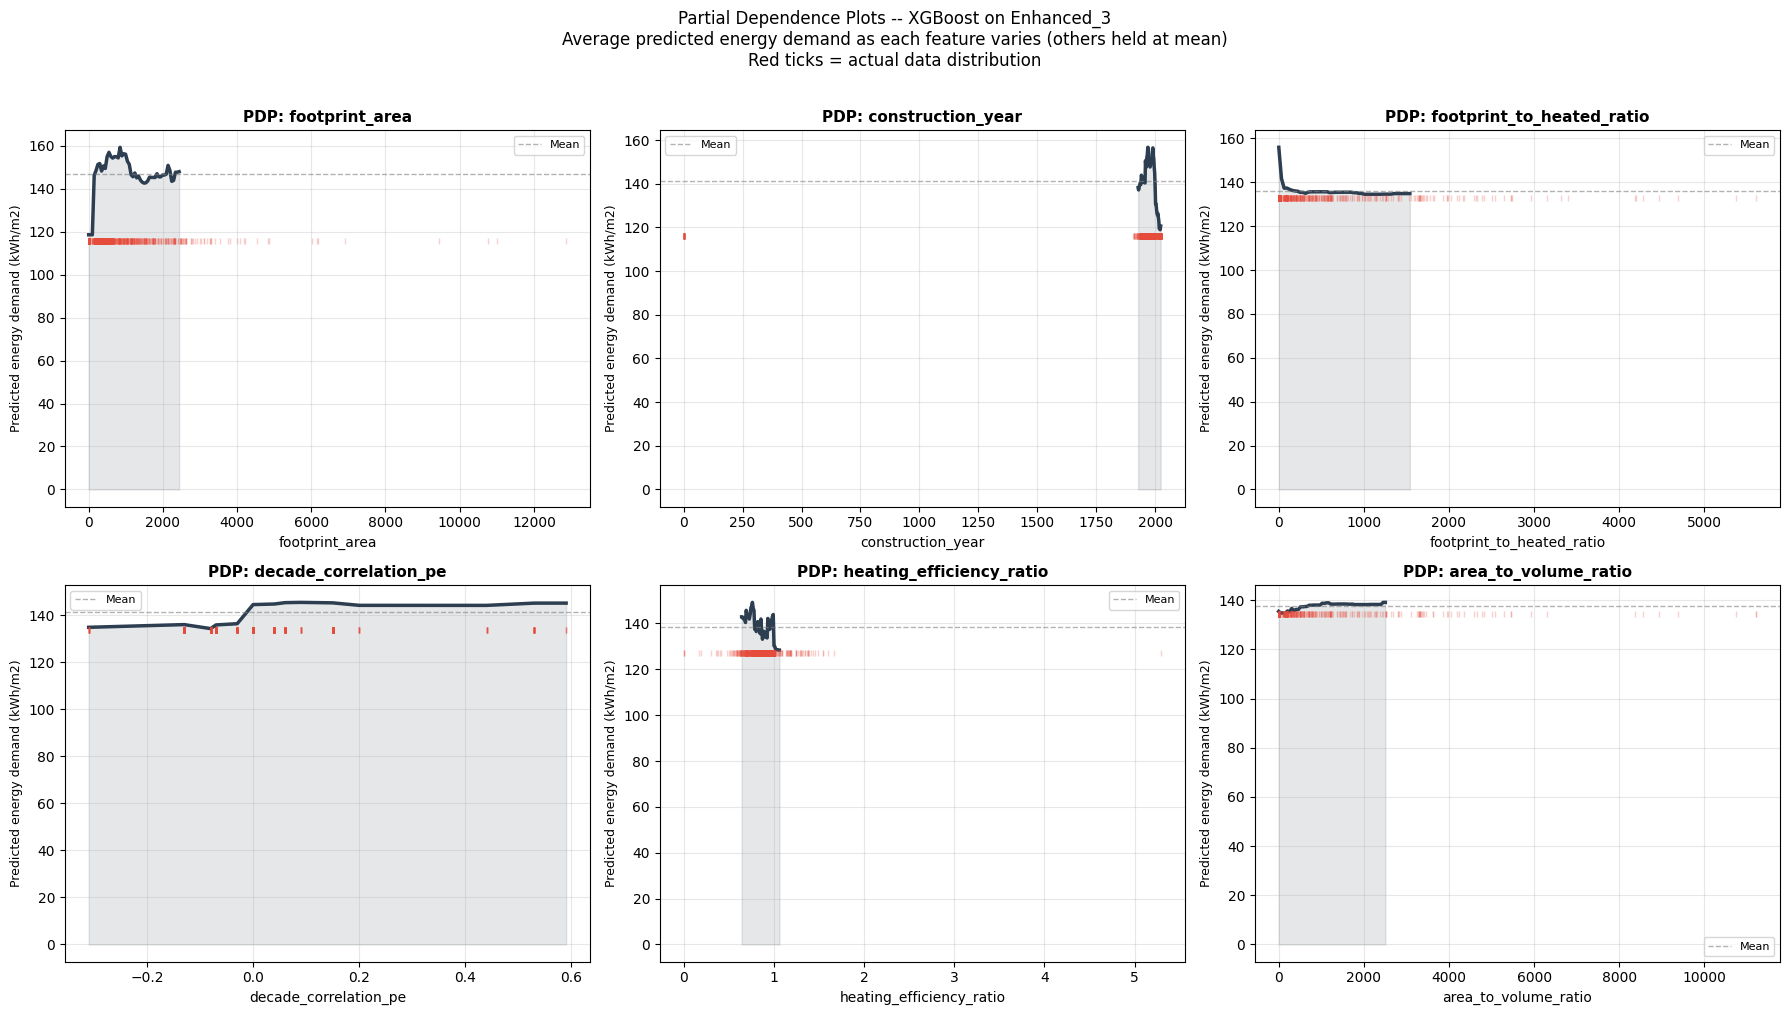

In [36]:
def run_pdp_analysis(df, target_column='en2025_enegy_demand_present_m2',
                     pdp_features=None, n_features=6, grid_resolution=50):
    import xgboost as xgb
    from sklearn.inspection import partial_dependence

    X, y_t, use_log, idx_tr, idx_te, feat_names, _, _ = \
        _build_enhanced3(df, target_column)
    X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
    y_tr, y_te = y_t.iloc[idx_tr], y_t.iloc[idx_te]

    print('Training XGBoost...', end=' ', flush=True)
    model = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    )
    model.fit(X_tr, y_tr)
    print('done')

    if pdp_features is None:
        if SHAP_AVAILABLE:
            expl = shap.TreeExplainer(model)
            sv   = expl.shap_values(X_te)
            imp  = pd.Series(np.abs(sv).mean(axis=0), index=feat_names)
        else:
            imp = pd.Series(model.feature_importances_, index=feat_names)
        pdp_features = imp.sort_values(ascending=False).head(n_features).index.tolist()

    print('PDP features: ' + str(pdp_features))

    ncols = min(3, len(pdp_features))
    nrows = int(np.ceil(len(pdp_features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax, feat in zip(axes_flat, pdp_features):
        feat_idx  = feat_names.index(feat)
        pd_res    = partial_dependence(model, X_tr, features=[feat_idx],
                                       kind='average', grid_resolution=grid_resolution)
        grid_vals = pd_res['grid_values'][0]
        avg_pred  = pd_res['average'][0]
        y_vals    = np.expm1(avg_pred) if use_log else avg_pred

        ax.plot(grid_vals, y_vals, color='#2c3e50', linewidth=2.5)
        ax.fill_between(grid_vals, y_vals, alpha=0.12, color='#2c3e50')

        feat_data = X_tr.iloc[:, feat_idx].values
        y_rug = np.full_like(feat_data, y_vals.min() - (y_vals.max() - y_vals.min()) * 0.07)
        ax.plot(feat_data, y_rug, '|', color='#e74c3c', alpha=0.25, markersize=5)

        ax.axhline(y_vals.mean(), color='grey', linestyle='--', linewidth=1, alpha=0.6, label='Mean')
        ax.set_xlabel(feat, fontsize=10)
        ax.set_ylabel('Predicted energy demand (kWh/m2)', fontsize=9)
        ax.set_title('PDP: ' + feat, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    for ax in axes_flat[len(pdp_features):]:
        ax.set_visible(False)

    plt.suptitle(
        'Partial Dependence Plots -- XGBoost on Enhanced_3\n'
        'Average predicted energy demand as each feature varies (others held at mean)\n'
        'Red ticks = actual data distribution',
        fontsize=12, y=1.01
    )
    plt.tight_layout(); plt.show()
    return model


# Run PDP analysis
xgb_model_pdp = run_pdp_analysis(overlapping_gdf_dataset)